# Modelo red neuronal LSTM + Attention.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
Sa_Crustal = ['T_0.01_RotD50', 'T_0.02_RotD50', 'T_0.03_RotD50', 'T_0.04_RotD50',
       'T_0.05_RotD50','T_0.075_RotD50','T_0.1_RotD50','T_0.15_RotD50','T_0.2_RotD50','T_0.25_RotD50','T_0.3_RotD50',
        'T_0.4_RotD50','T_0.5_RotD50','T_0.75_RotD50','T_1.0_RotD50','T_1.5_RotD50','T_2.0_RotD50','T_3.0_RotD50',
        'T_4.0_RotD50','T_5.0_RotD50','T_6.0_RotD50','T_10.0_RotD50']

In [4]:
df = pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/FinalProjectDL/Final_Project/Updated_NGA_West2_Flatfile_RotD50EDITADO.xlsx')
df = df[df['Vs30 (m/s) selected for analysis'] > 0]
df = df[df['Magnitude Type'] == 'Mw']

In [5]:
df.drop(columns=['Record Sequence Number','Earthquake Name',
                'Magnitude Type','EpiD (km)','Joyner-Boore Dist. (km)',
                'RmsD (km)','Rx','Vs30 (m/s) selected for analysis',
                #'Tmax',
                 'Lowest Usable Freq - Ave. Component (Hz)',
                'PGA (g)','PGV (cm/sec)','PGD (cm)'], inplace=True)

In [6]:
inputs = df.columns[0:9]

In [7]:
var = inputs.tolist() + Sa_Crustal

In [8]:
df_Col = pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/FinalProjectDL/Final_Project/CopiaDataBaseSGC.xlsx')
df_Col[Sa_Crustal]=df_Col[Sa_Crustal]/980

In [9]:
columnas_a_eliminar = [
    "Record Sequence Number", "Station ID", "Station Code", "Magnitude type", "EQID", "Valor_T1.5",
    #"Tmax", 
    #"Epicenter Latitude (deg; positive N)", "Epicenter Longitude (deg; positive E)",
    #"Station Latitude (deg positive N)", "Station Longitude (deg positive E)",
    "Topografía", "Geología",
    "Nodal Plane 1 Rake Angle (deg)", "Nodal Plane 2 Rake Angle (deg)",
    "Nodal Plane 2 Dip (deg)", "Nodal Plane 2 Strike (deg)",
    "Rx_OpenQuake", "Ry0_OpenQuake", "Rjb_OpenQuake",
    "Repi_OpenQuake",
    # "Rhypo_OpenQuake",
    "Station Elevation (m)",
    #"Soil_Class",
    "Nodal Plane 1 Strike (deg)", "Nodal Plane 1 Dip (deg)",
    "Fault Plane (1; 2; X)", "Style-of-Faulting (S; R; N; U)",
    "Tn",
    'Record Sequence Number','EQID','Magnitude type',
    'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'
]

In [10]:
df_Col = df_Col[df_Col['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']=='Crustal']

In [11]:
df_Col.drop(columns=columnas_a_eliminar, inplace=True)

In [12]:
df_Col = df_Col[df_Col['T_0.01_RotD50']>=1e-7]

In [13]:
df = df.rename(columns={"Hypocenter Latitude (deg)": "Seismic Latitude"})
df = df.rename(columns={"Hypocenter Longitude (deg)": "Seismic Longitude"})
df_Col = df_Col.rename(columns={"Epicenter Latitude (deg; positive N)": "Seismic Latitude"})
df_Col = df_Col.rename(columns={"Epicenter Longitude (deg; positive E)": "Seismic Longitude"})
df_Col = df_Col.rename(columns={"Station Latitude (deg positive N)": "Station Latitude"})
df_Col = df_Col.rename(columns={"Station Longitude (deg positive E)": "Station Longitude"})

In [14]:
inputs = df.columns[0:9]
inputs

Index(['Seismic Latitude', 'Seismic Longitude', 'Station Latitude',
       'Station Longitude', 'Hypocenter Depth (km)', 'Magnitude',
       'Rhypo_OpenQuake', 'Rrup_OpenQuake', 'Soil_Class'],
      dtype='object')

In [15]:
var = inputs.tolist() + Sa_Crustal
df_Col=df_Col[var]

In [16]:
df_Col['origen'] = 'Colombia'
df['origen'] = 'NGAW2'

In [17]:
df_total = pd.concat([df, df_Col], ignore_index=True)

In [18]:
df_total

,Seismic Latitude,Seismic Longitude,Station Latitude,Station Longitude,Hypocenter Depth (km),Magnitude,Rhypo_OpenQuake,Rrup_OpenQuake,Soil_Class,Tmax,...,T_0.75_RotD50,T_1.0_RotD50,T_1.5_RotD50,T_2.0_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_10.0_RotD50,origen
0,46.6100,-111.9600,46.5800,-112.0300,6.0,6.0000,8.710000,2.860000,3,6.153846,...,0.092829,0.101136,0.059109,0.035895,1.525704e-02,7.987177e-03,4.643577e-03,3.036607e-03,NaN,NGAW2
1,40.4000,-125.1000,40.5760,-124.2630,10.0,5.8000,74.170000,71.570000,4,2.666667,...,0.056946,0.035785,0.016157,0.009347,2.959554e-03,NaN,NaN,NaN,NaN,NGAW2
2,40.3000,-124.8000,40.5760,-124.2630,10.0,5.5000,55.780000,53.580000,4,1.600000,...,0.091499,0.093659,0.026785,0.013654,NaN,NaN,NaN,NaN,NaN,NGAW2
3,32.7601,-115.4162,32.7940,-115.5490,8.8,6.9500,15.690000,6.090000,4,4.000000,...,0.435350,0.351286,0.197357,0.215745,1.063604e-01,4.696507e-02,NaN,NaN,NaN,NGAW2
4,40.2830,-124.8000,40.5760,-124.2630,10.0,5.8000,56.850000,53.770000,4,2.000000,...,0.124190,0.085661,0.040947,0.019499,NaN,NaN,NaN,NaN,NaN,NGAW2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17507,3.4400,-74.1900,1.1890,-77.3220,10.0,4.1000,428.905798,428.091130,5,NaN,...,0.000002,0.000001,0.000001,0.000001,1.087456e-06,6.427327e-07,3.359714e-07,2.371388e-07,6.632653e-08,Colombia
17508,3.4300,-74.2000,1.1890,-77.3220,18.0,4.0000,427.631871,426.956629,5,NaN,...,0.000002,0.000001,0.000001,0.000001,9.019724e-07,4.762469e-07,2.486122e-07,1.713980e-07,6.234694e-08,Colombia
17509,3.4100,-74.1700,1.2097,-77.2563,15.0,4.3000,421.640421,420.098899,5,NaN,...,0.000013,0.000008,0.000003,0.000004,2.928746e-06,2.381339e-06,2.458191e-06,1.652310e-06,3.452092e-07,Colombia
17510,7.2700,-78.6400,1.2097,-77.2563,4.0,5.1000,691.759807,689.662530,5,NaN,...,0.000003,0.000002,0.000002,0.000002,8.369194e-07,4.056827e-07,2.166969e-07,1.402816e-07,4.969388e-08,Colombia


In [19]:
df_total.drop(columns=['Seismic Latitude', 'Seismic Longitude', 'Station Latitude','Station Longitude'], inplace=True)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
df_total = df_total[df_total['T_0.01_RotD50'] > 10e-6]

In [22]:
df_30_35 = df_total[(df_total["Magnitude"] >= 3.0) & (df_total["Magnitude"] < 3.5)]
df_35_40 = df_total[(df_total["Magnitude"] >= 3.5) & (df_total["Magnitude"] < 4.0)]
df_40_45 = df_total[(df_total["Magnitude"] >= 4.0) & (df_total["Magnitude"] < 4.5)]
df_45_50 = df_total[(df_total["Magnitude"] >= 4.5) & (df_total["Magnitude"] < 5.0)]
df_50_55 = df_total[(df_total["Magnitude"] >= 5.0) & (df_total["Magnitude"] < 5.5)]
df_55_60 = df_total[(df_total["Magnitude"] >= 5.5) & (df_total["Magnitude"] < 6.0)]
df_60_65 = df_total[(df_total["Magnitude"] >= 6.0) & (df_total["Magnitude"] < 6.5)]
df_65_70 = df_total[(df_total["Magnitude"] >= 6.5) & (df_total["Magnitude"] < 7.0)]
df_70_75 = df_total[(df_total["Magnitude"] >= 7.0) & (df_total["Magnitude"] < 7.5)]
df_75_80 = df_total[(df_total["Magnitude"] >= 7.5) & (df_total["Magnitude"] <= 8.0)]

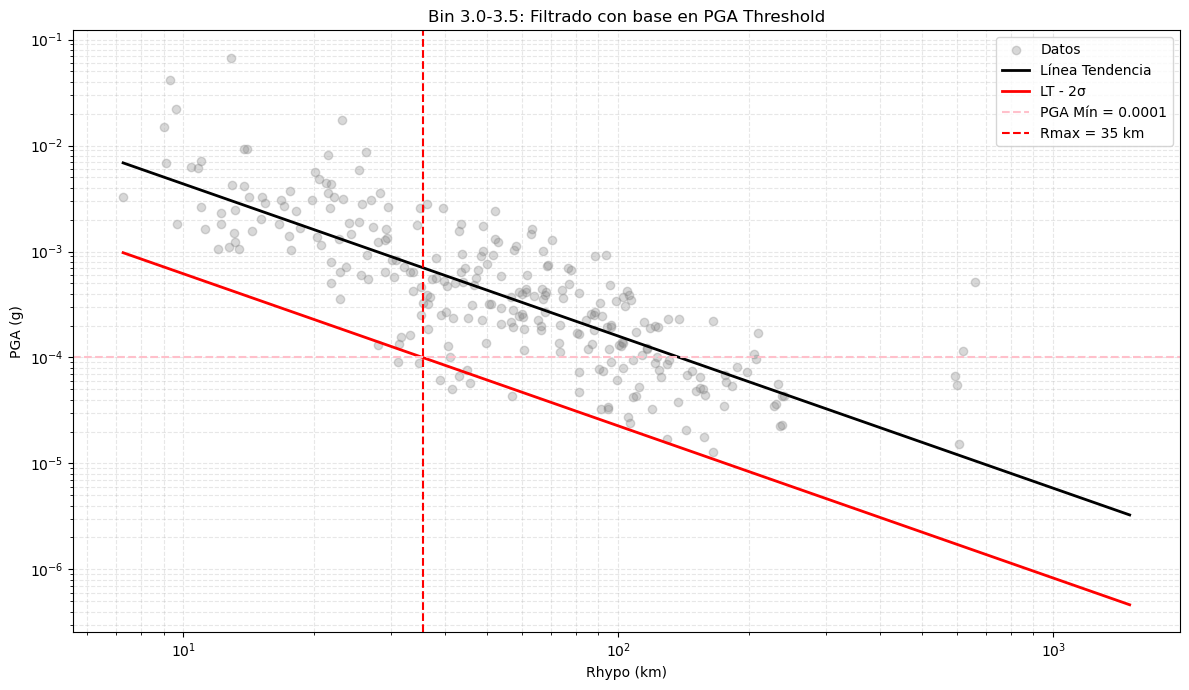

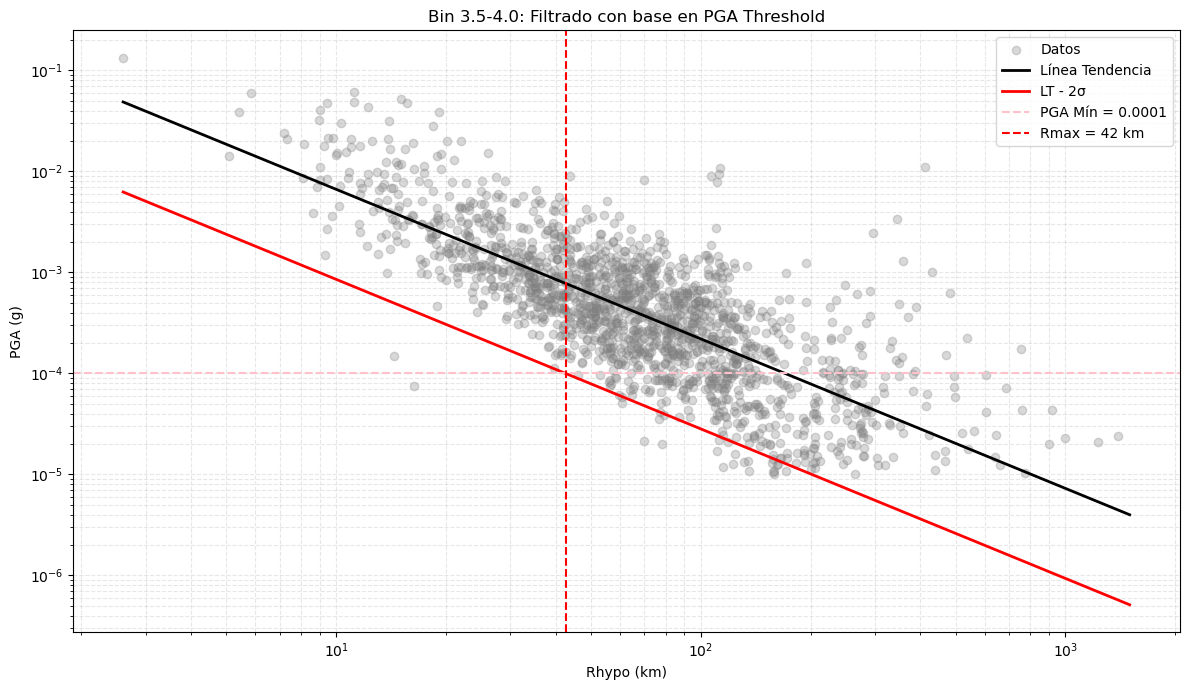

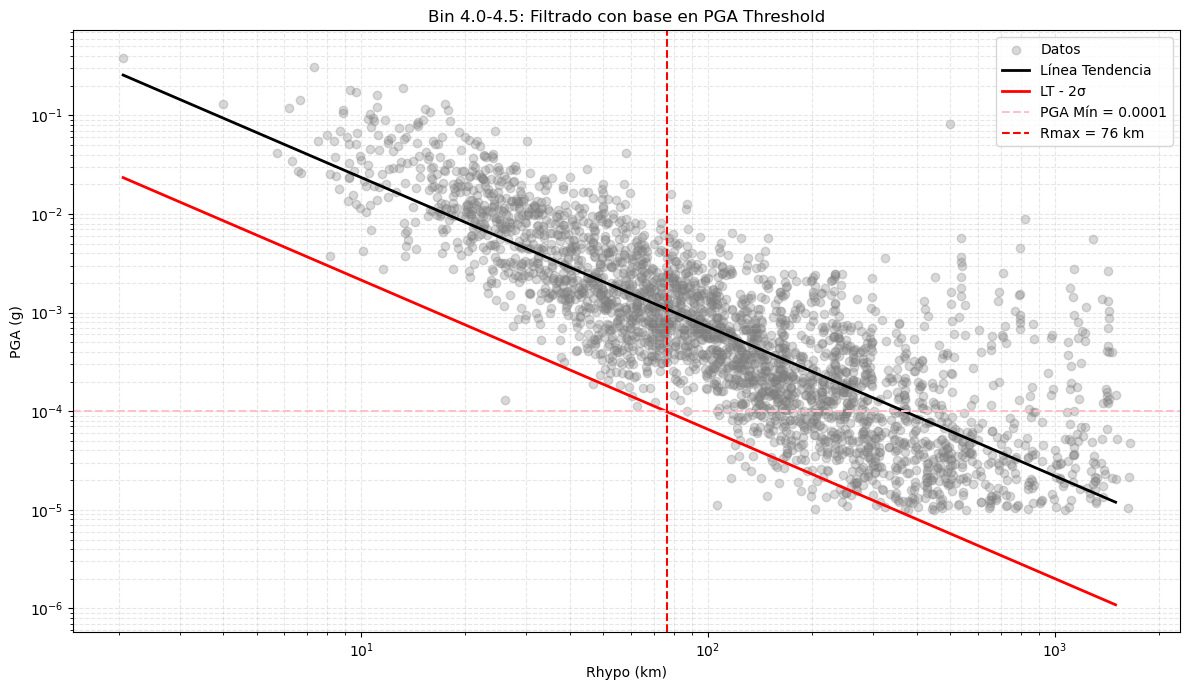

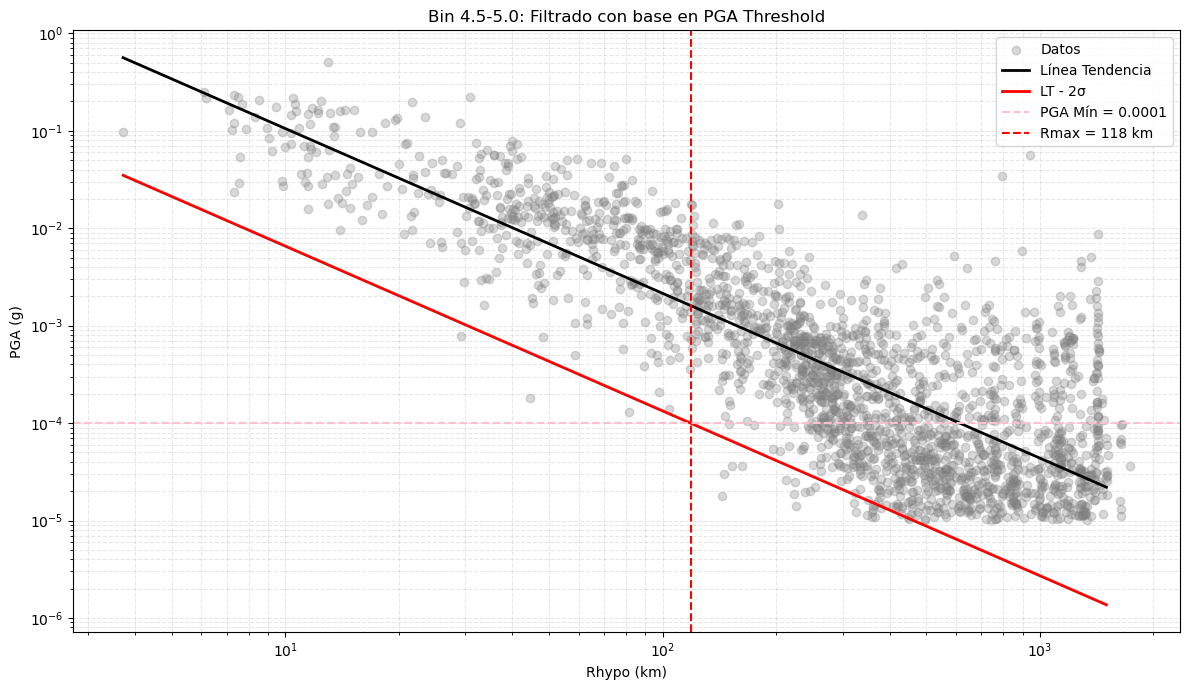

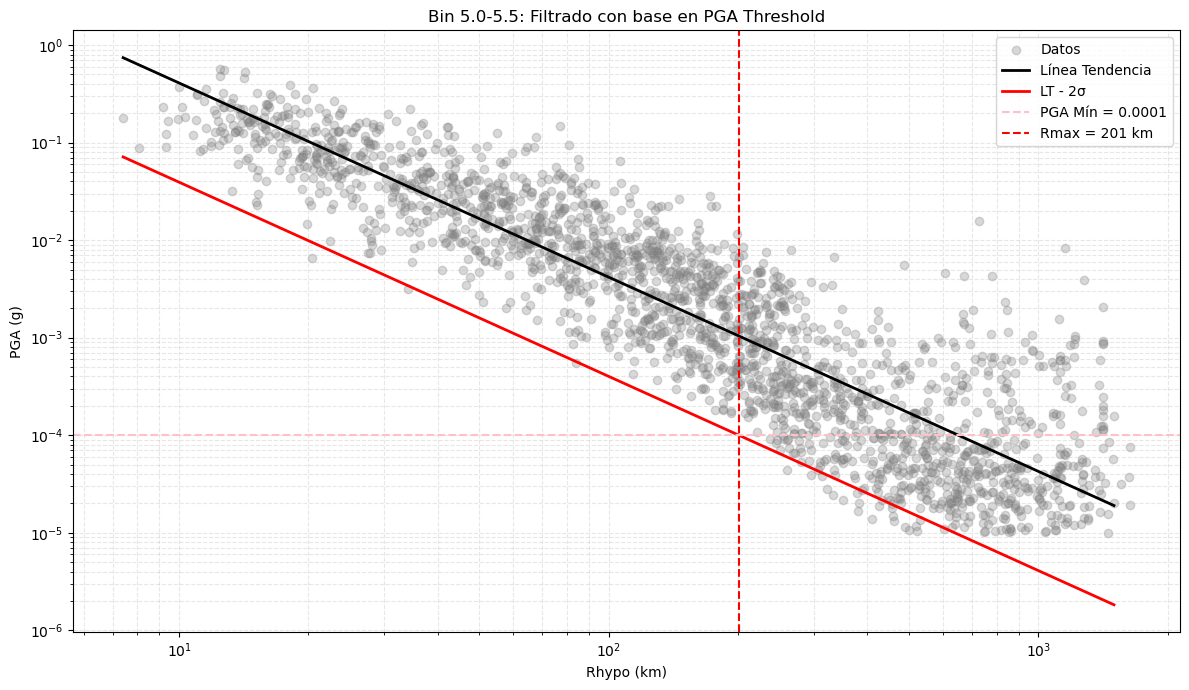

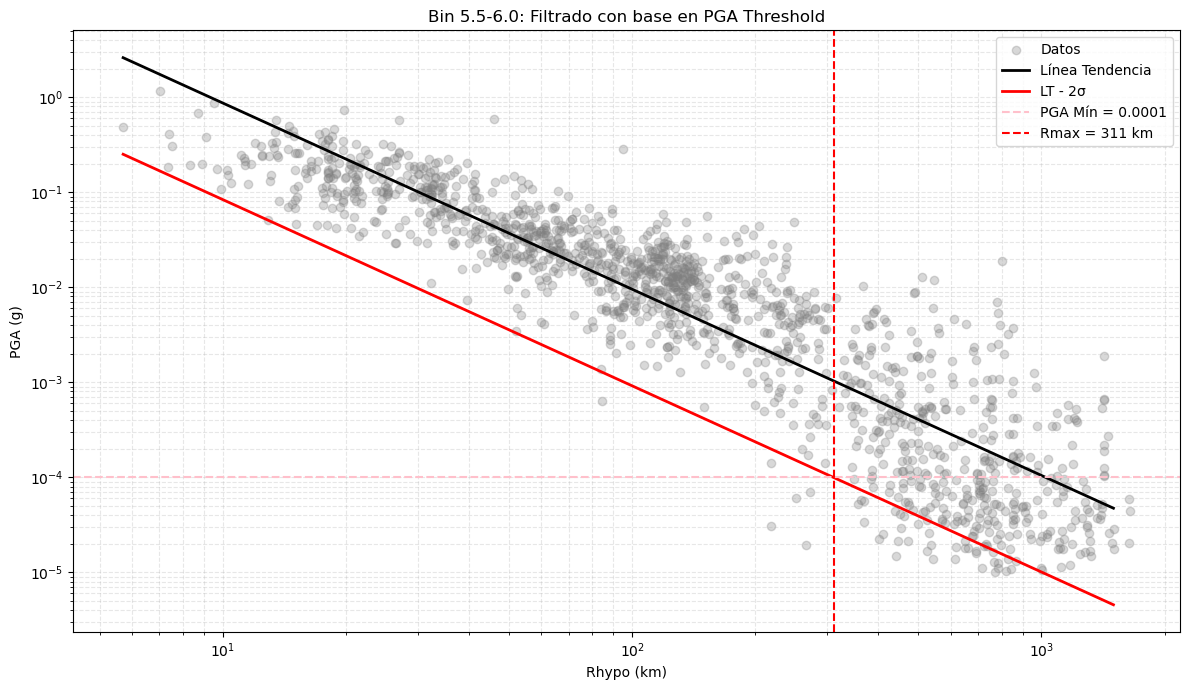

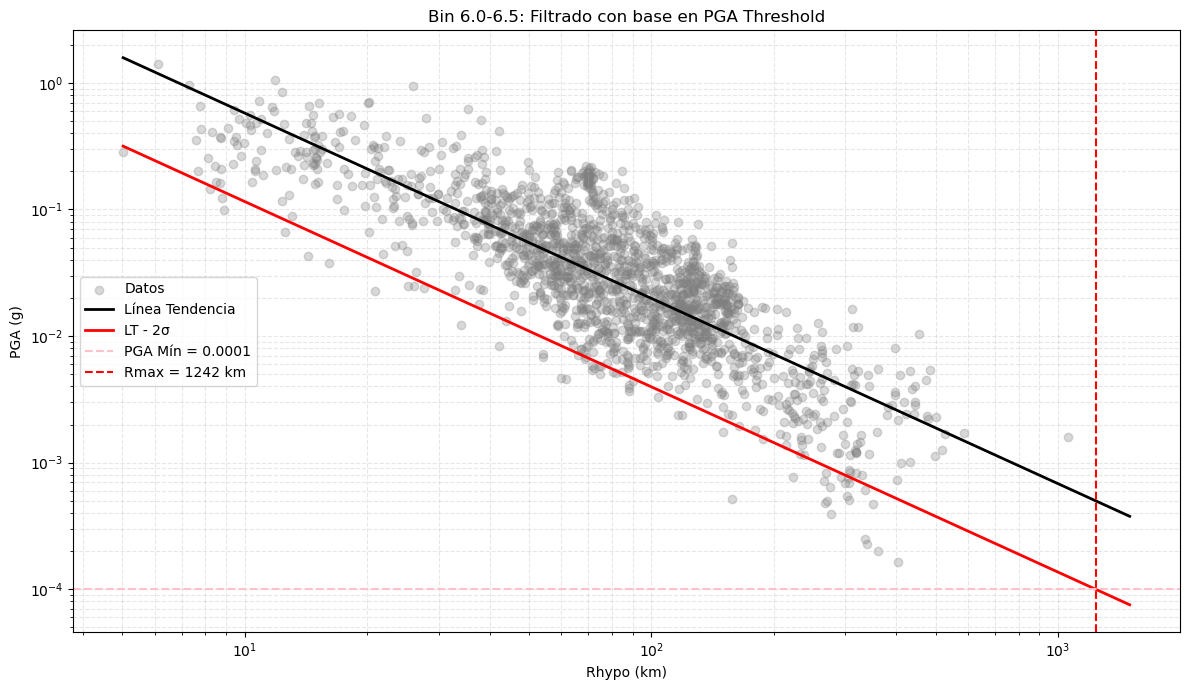

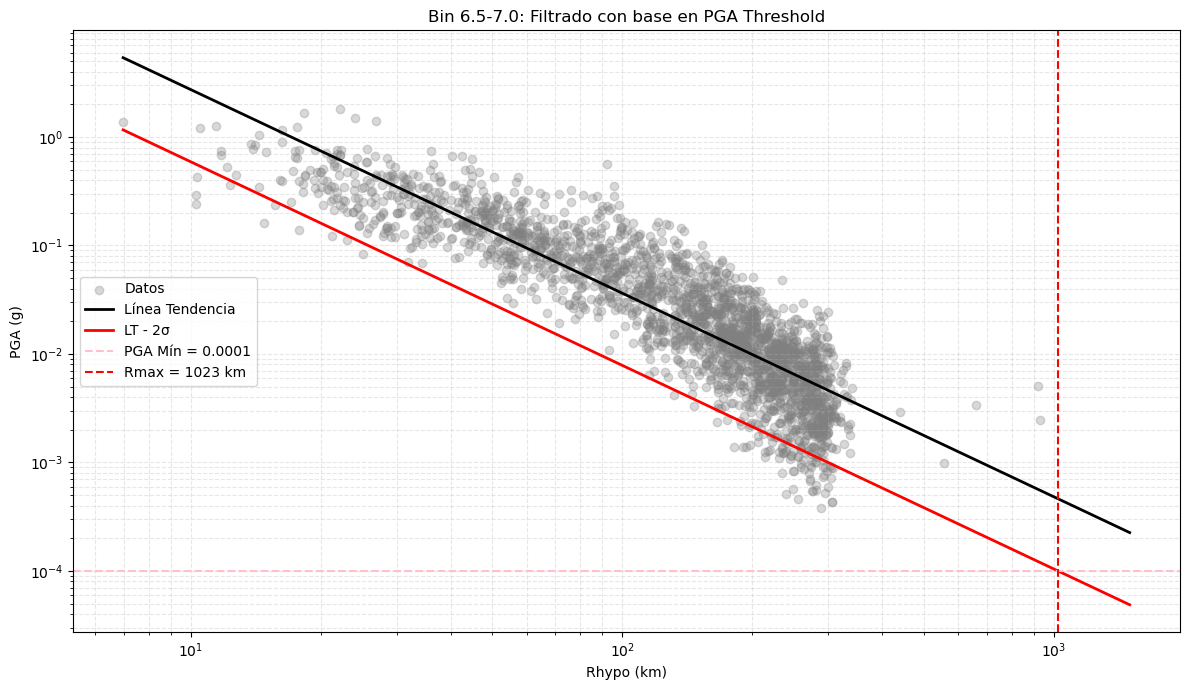

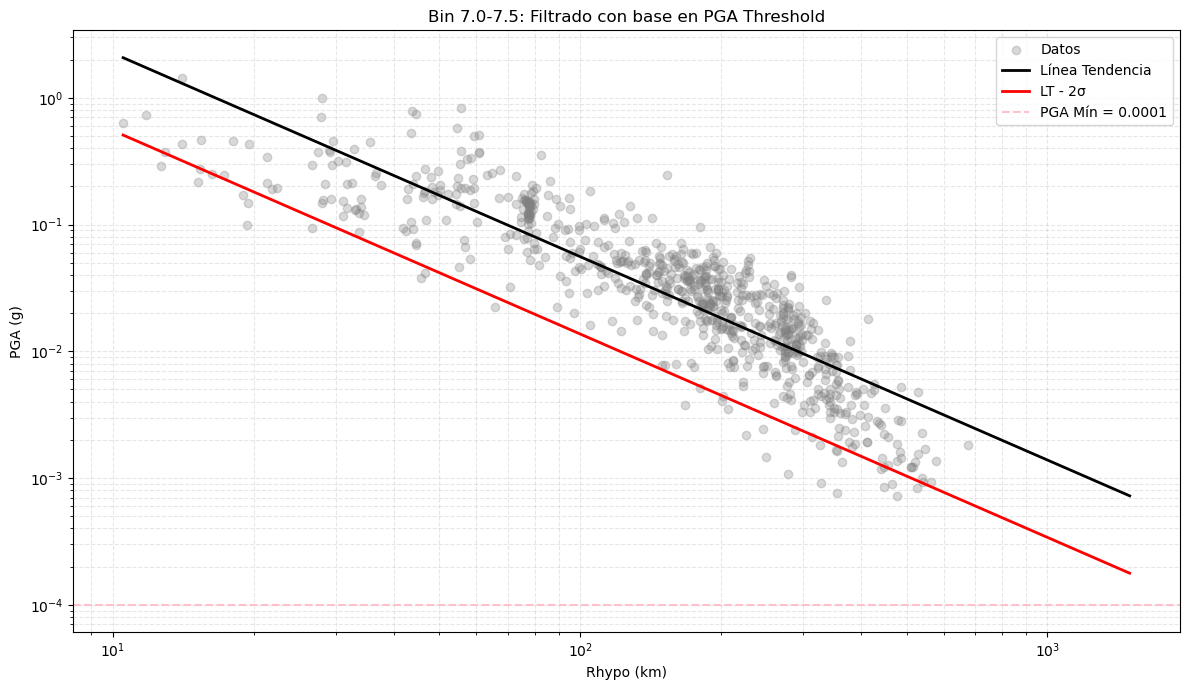

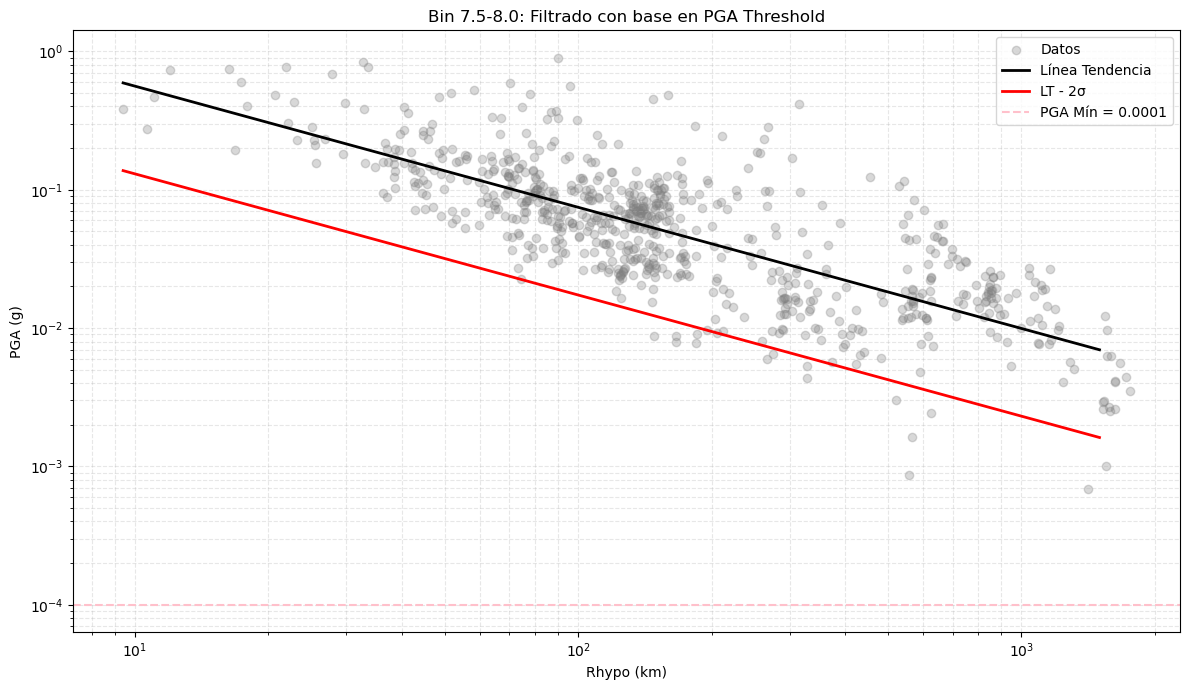

Resultados Rmax por bin:
3.0-3.5: 35.62906404860754
3.5-4.0: 42.79466013240592
4.0-4.5: 76.0450541153358
4.5-5.0: 118.97322286109743
5.0-5.5: 201.11636081673532
5.5-6.0: 311.2590138828386
6.0-6.5: 1242.5723936272595
6.5-7.0: 1023.9824377662434
7.0-7.5: None
7.5-8.0: None


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Definimos función para aplicar tu lógica
def analizar_bin(df, label, pga_min=1e-4, columna_x="Rhypo_OpenQuake", columna_y="T_0.01_RotD50"):
    x = df[columna_x]
    y = df[columna_y]
    
    # Filtrar datos sin NA y aplicar log10
    x_log = np.log10(x)
    y_log = np.log10(y)
    mask = (x_log.notna()) & (y_log.notna())
    x_log = x_log[mask].values.reshape(-1, 1)
    y_log = y_log[mask].values
    
    if len(x_log) < 10:  # evitar bins vacíos
        print(f"Bin {label} sin suficientes datos.")
        return None
    
    # Modelo de regresión lineal (log-log)
    modelo = LinearRegression()
    modelo.fit(x_log, y_log)
    
    # Línea de tendencia
    x_pred = np.logspace(np.log10(x.min()), np.log10(1500), 1000)
    x_pred_log = np.log10(x_pred).reshape(-1, 1)
    y_pred_log = modelo.predict(x_pred_log)
    
    # Desviación estándar de los residuos (hasta 20,000 km)
    residuos = y_log - modelo.predict(x_log)
    residuos_limite = residuos[x[mask].values <= 20000]
    sigma = np.std(residuos_limite)
    y_pred_log_2sigma = y_pred_log - 2 * sigma
    
    # Calcular intersección con PGA mínimo
    pga_min_log = np.log10(pga_min)
    idx_interseccion = np.where(y_pred_log_2sigma <= pga_min_log)[0]
    R_max = x_pred[idx_interseccion[0]] if len(idx_interseccion) > 0 else None
    
    # --- Gráfico ---
    plt.figure(figsize=(12, 7))
    plt.scatter(x, y, alpha=0.3, label="Datos", color='gray')
    plt.plot(x_pred, 10**y_pred_log, color='black', label="Línea Tendencia", linewidth=2)
    plt.plot(x_pred, 10**y_pred_log_2sigma, color='red', label="LT - 2σ", linewidth=2)
    plt.axhline(y=pga_min, color='pink', linestyle='--', label=f"PGA Mín = {pga_min:g}")
    
    if R_max:
        plt.axvline(x=R_max, color='red', linestyle='--', label=f"Rmax = {int(R_max)} km")
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Rhypo (km)")
    plt.ylabel("PGA (g)")
    plt.title(f"Bin {label}: Filtrado con base en PGA Threshold")
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return R_max

# --- Diccionario con tus dataframes ---
bins_dict = {
    "3.0-3.5": df_30_35,
    "3.5-4.0": df_35_40,
    "4.0-4.5": df_40_45,
    "4.5-5.0": df_45_50,
    "5.0-5.5": df_50_55,
    "5.5-6.0": df_55_60,
    "6.0-6.5": df_60_65,
    "6.5-7.0": df_65_70,
    "7.0-7.5": df_70_75,
    "7.5-8.0": df_75_80
}

# --- Iterar sobre todos los bins ---
Rmax_results = {}
for label, df_bin in bins_dict.items():
    Rmax_results[label] = analizar_bin(df_bin, label)

# Ver resultados
print("Resultados Rmax por bin:")
for label, rmax in Rmax_results.items():
    print(f"{label}: {rmax}")


In [24]:
# Filtrar cada bin con su respectivo Rmax
df30_35 = df_30_35[df_30_35['Rhypo_OpenQuake'] <= Rmax_results["3.0-3.5"]]
df35_40 = df_35_40[df_35_40['Rhypo_OpenQuake'] <= Rmax_results["3.5-4.0"]]
df40_45 = df_40_45[df_40_45['Rhypo_OpenQuake'] <= Rmax_results["4.0-4.5"]]
df45_50 = df_45_50[df_45_50['Rhypo_OpenQuake'] <= Rmax_results["4.5-5.0"]]
df50_55 = df_50_55[df_50_55['Rhypo_OpenQuake'] <= Rmax_results["5.0-5.5"]]
df55_60 = df_55_60[df_55_60['Rhypo_OpenQuake'] <= Rmax_results["5.5-6.0"]]
df60_65 = df_60_65[df_60_65['Rhypo_OpenQuake'] <= Rmax_results["6.0-6.5"]]
df65_70 = df_65_70[df_65_70['Rhypo_OpenQuake'] <= Rmax_results["6.5-7.0"]]
#df70_75 = df_70_75[df_70_75['Rhypo_OpenQuake'] <= Rmax_results["7.0-7.5"]]
#df75_80 = df_75_80[df_75_80['Rhypo_OpenQuake'] <= Rmax_results["7.5-8.0"]]
df70_75 = df_70_75
df75_80 = df_75_80
# Concatenar todos los bins ya filtrados
df_total2 = pd.concat(
    [df30_35, df35_40, df40_45, df45_50, df50_55,
     df55_60, df60_65, df65_70, df70_75, df75_80],
    ignore_index=True
)

# Copiar y aplicar filtro final de PGA
df_total = df_total2.copy()
df_total = df_total[df_total['T_0.01_RotD50'] > 1e-4]



In [25]:
df_total

,Hypocenter Depth (km),Magnitude,Rhypo_OpenQuake,Rrup_OpenQuake,Soil_Class,Tmax,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_0.75_RotD50,T_1.0_RotD50,T_1.5_RotD50,T_2.0_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_10.0_RotD50,origen
0,7.213,3.4,12.75630,12.22,2,0.808081,0.001092,0.001078,0.001453,0.002399,...,0.000467,0.000183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
1,7.213,3.4,27.33596,27.03,3,1.081081,0.001714,0.001696,0.001745,0.002034,...,0.000513,0.000254,0.000067,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
2,7.213,3.4,35.07003,34.85,3,1.081081,0.002577,0.002538,0.002716,0.003008,...,0.000491,0.000322,0.000082,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
3,7.213,3.4,20.55230,20.07,3,1.333333,0.004874,0.005332,0.006315,0.008871,...,0.000329,0.000171,0.000060,NaN,NaN,NaN,NaN,NaN,NaN,NGAW2
4,8.469,3.4,12.84512,12.51,3,1.666667,0.067464,0.071776,0.104458,0.115679,...,0.001890,0.001022,0.000448,0.000245,NaN,NaN,NaN,NaN,NaN,NGAW2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10241,10.040,7.9,609.00000,441.95,3,20.000000,0.011848,0.011885,0.011950,0.012048,...,0.016969,0.013162,0.011378,0.012016,0.007713,0.007323,0.009168,0.011108,0.005309,NGAW2
10242,10.040,7.9,537.99000,362.18,3,26.666667,0.013792,0.013822,0.013872,0.013959,...,0.025694,0.023990,0.015413,0.018298,0.011543,0.008223,0.008980,0.008458,0.005573,NGAW2
10243,10.040,7.9,540.10000,376.08,2,26.666667,0.011857,0.011864,0.011873,0.011891,...,0.027657,0.025381,0.019319,0.020109,0.007606,0.005916,0.006102,0.008619,0.006396,NGAW2
10244,10.040,7.9,556.05000,416.48,3,13.333333,0.011815,0.011839,0.011880,0.011948,...,0.014408,0.019274,0.011439,0.008004,0.006273,0.004877,0.004101,0.006534,0.004158,NGAW2


In [26]:
df_total.drop(columns=['Rhypo_OpenQuake'], inplace=True)

In [27]:
df_total[Sa_Crustal]=np.log(df_total[Sa_Crustal])
df_total["Rrup_OpenQuake"]=np.log(df_total["Rrup_OpenQuake"])

In [28]:

# 1) Detectar columnas de periodos
cols_T = [c for c in df_total.columns if re.match(r'^T_\d+(\.\d+)?_RotD50$', c)]

# 2) Extraer el valor del periodo de cada columna (float)
def col_to_T(c):
    # de 'T_0.01_RotD50' -> 0.01
    return float(c.split('_')[1])

periods = np.array([col_to_T(c) for c in cols_T])  # shape (nT,)

# 3) Construir máscara por-fila: True donde T > Tmax (invalidar)
Tmax = df_total['Tmax'].to_numpy().reshape(-1, 1)       # shape (n,1)
mask = periods.reshape(1, -1) > Tmax              # shape (n, nT)

# 4) Aplicar NaN solo en los inválidos (¡sin loops!)
df_total.loc[:, cols_T] = df_total.loc[:, cols_T].mask(mask)


## Modelamiento

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [30]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers, Sequential

In [31]:
def masked_mse(y_true, y_pred):
    """
    MSE que ignora los NaN de y_true.
    Promedia por muestra (solo sobre entradas válidas) y luego promedia el batch.
    """
    # máscara: 1 donde y_true es válido, 0 donde es NaN
    mask = tf.cast(~tf.math.is_nan(y_true), tf.float32)

    # reemplaza NaN por 0 (no afecta porque se multiplica por mask)
    y_true_f = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)

    # error cuadrático por elemento y enmascarado
    se = tf.square(y_pred - y_true_f) * mask

    # ejes a reducir (todos menos el batch: 0)
    reduce_axes = tf.range(1, tf.rank(y_true))

    # suma de errores y conteo de válidos por muestra
    se_sum   = tf.reduce_sum(se, axis=reduce_axes)
    n_valid  = tf.reduce_sum(mask, axis=reduce_axes)

    # MSE por muestra (evitando división por cero)
    mse_per_sample = se_sum / (n_valid + 1e-8)

    # promedio del batch
    return tf.reduce_mean(mse_per_sample)
    
def masked_mae(y_true, y_pred):
    mask = tf.cast(~tf.math.is_nan(y_true), tf.float32)
    y_true_f = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)
    ae = tf.abs(y_pred - y_true_f) * mask
    reduce_axes = tf.range(1, tf.rank(y_true))
    ae_sum  = tf.reduce_sum(ae, axis=reduce_axes)
    n_valid = tf.reduce_sum(mask, axis=reduce_axes)
    mae_per_sample = ae_sum / (n_valid + 1e-8)
    return tf.reduce_mean(mae_per_sample)

In [32]:
inputs = ['Magnitude', 'Rrup_OpenQuake', 'Hypocenter Depth (km)', 'Soil_Class','origen']
outputs = Sa_Crustal  

In [33]:
num_features = ['Magnitude', 'Rrup_OpenQuake', 'Hypocenter Depth (km)']
cat_features = ['Soil_Class', 'origen']

In [34]:
df_total[cat_features] = df_total[cat_features].astype(str)

In [35]:
X = df_total[inputs]
y = df_total[Sa_Crustal]

In [36]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=0, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=0, shuffle=True
)

In [37]:
num_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

cat_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features)
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [38]:
X_train_feats = pre.fit_transform(X_train)
X_val_feats   = pre.transform(X_val)
X_test_feats  = pre.transform(X_test)

In [39]:
X_train_feats

array([[ 0.19604934,  0.90089962,  1.22396476, ...,  1.        ,
         1.        ,  0.        ],
       [ 1.49961367, -0.33764404, -0.51547842, ...,  0.        ,
         0.        ,  1.        ],
       [-0.71324057,  0.29555981,  0.27693458, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.65651422,  0.55415743,  8.39433608, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.49961367, -2.49693573, -0.51547842, ...,  0.        ,
         0.        ,  1.        ],
       [-0.4058997 ,  0.66551801, -0.61481995, ...,  0.        ,
         0.        ,  1.        ]])

### LSTM

In [40]:
# Datos -> numpy
Xtr = np.asarray(X_train_feats, dtype="float32")
Xva = np.asarray(X_val_feats,   dtype="float32")
Xte = np.asarray(X_test_feats,  dtype="float32")

Ytr = np.asarray(y_train, dtype="float32")
Yva = np.asarray(y_val, dtype="float32")
Yte = np.asarray(y_test, dtype="float32")
if Ytr.ndim == 1: Ytr = Ytr.reshape(-1,1)
if Yva.ndim == 1: Yva = Yva.reshape(-1,1)
if Yte.ndim == 1: Yte = Yte.reshape(-1,1)

n_features = Xtr.shape[1]
nT = Ytr.shape[1]

# RNN input shape: (batch, timesteps, features) — tratamos cada columna como timestep
Xtr_rnn = Xtr.reshape((-1, n_features, 1))
Xva_rnn = Xva.reshape((-1, n_features, 1))
Xte_rnn = Xte.reshape((-1, n_features, 1))

tf.keras.utils.set_random_seed(42)

inp = Input(shape=(n_features, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.LSTM(64)(x)
x = layers.Dense(64, activation="relu")(x)
#x = layers.Dropout(0.15)(x)
out = layers.Dense(nT, activation=None)(x)

modelLSTM = Model(inp, out)
modelLSTM.compile(optimizer=optimizers.Adam(1e-3), loss=masked_mse)

es  = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6)

history = modelLSTM.fit(
    Xtr_rnn, Ytr,
    validation_data=(Xva_rnn, Yva),
    epochs=400, batch_size=64,
    callbacks=[es, rlr], verbose=1
)

print("Test loss:", modelLSTM.evaluate(Xte_rnn, Yte, verbose=0))
y_pred_test = modelLSTM.predict(Xte_rnn)   # (n_samples, nT)


Epoch 1/400

112/112 [==============================] - 6s 18ms/step - loss: 7.8777 - val_loss: 2.9218 - lr: 0.0010
Epoch 2/400
112/112 [==============================] - 1s 10ms/step - loss: 2.5336 - val_loss: 1.9187 - lr: 0.0010
Epoch 3/400
112/112 [==============================] - 1s 10ms/step - loss: 1.8624 - val_loss: 1.6212 - lr: 0.0010
Epoch 4/400
112/112 [==============================] - 1s 11ms/step - loss: 1.5509 - val_loss: 1.2438 - lr: 0.0010
Epoch 5/400
112/112 [==============================] - 1s 11ms/step - loss: 1.2444 - val_loss: 1.1136 - lr: 0.0010
Epoch 6/400
112/112 [==============================] - 1s 10ms/step - loss: 1.1490 - val_loss: 1.0083 - lr: 0.0010
Epoch 7/400
112/112 [==============================] - 1s 10ms/step - loss: 1.1652 - val_loss: 1.0748 - lr: 0.0010
Epoch 8/400
112/112 [==============================] - 1s 10ms/step - loss: 1.0614 - val_loss: 0.9308 - lr: 0.0010
Epoch 9/400
112/112 [==============================] - 1s 10ms/step - loss: 0.

In [41]:
# ====== BLOQUE 2: Métricas por periodo (TEST) ======

# Nombres de salidas: usa tu lista de columnas objetivo
y_names = list(Sa_Crustal) if 'Sa_Crustal' in globals() else [f"Y_{j}" for j in range(Yte.shape[1])]
if len(y_names) != Yte.shape[1]: y_names = [f"Y_{j}" for j in range(Yte.shape[1])]

# Si entrenaste en log(Sa) y quieres métricas en escala original, activa:
EXP_BACKTRANS = False

Y_te_eval  = np.exp(Yte)        if EXP_BACKTRANS else Yte
Yp_te_eval = np.exp(y_pred_test) if EXP_BACKTRANS else y_pred_test

rows_test = []
for j, name in enumerate(y_names):
    y_t = Y_te_eval[:, j]; y_p = Yp_te_eval[:, j]
    m = np.isfinite(y_t) & np.isfinite(y_p)
    if m.sum() == 0:
        rows_test.append({"Y": name, "RMSE": np.nan, "MSE": np.nan, "MAE": np.nan, "MAPE_%": np.nan, "R2": np.nan})
        continue
    err  = y_p[m] - y_t[m]
    mse  = np.mean(err**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(err))
    mm   = (np.abs(y_t) > 1e-12) & m
    mape = np.mean(np.abs((y_p[mm] - y_t[mm]) / y_t[mm])) * 100.0 if mm.sum() else np.nan
    y_mean = np.mean(y_t[m])
    ss_res = np.sum((y_t[m] - y_p[m])**2)
    ss_tot = np.sum((y_t[m] - y_mean)**2)
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rows_test.append({"Y": name, "RMSE": rmse, "MSE": mse, "MAE": mae, "MAPE_%": mape, "R2": r2})

df_test_metrics_lstm = pd.DataFrame(rows_test).set_index("Y").sort_index()
df_test_metrics_lstm 

,RMSE,MSE,MAE,MAPE_%,R2
Y,,,,,
T_0.01_RotD50,0.724621,0.525076,0.569467,18.853998,0.815360
T_0.02_RotD50,0.725180,0.525885,0.569407,18.571556,0.815767
T_0.03_RotD50,0.731643,0.535301,0.574776,18.807518,0.813957
T_0.04_RotD50,0.741044,0.549147,0.583495,21.650474,0.810115
T_0.05_RotD50,0.751450,0.564678,0.591935,22.400890,0.806778
T_0.075_RotD50,0.791743,0.626856,0.626087,30.041322,0.788956
T_0.15_RotD50,0.788633,0.621942,0.619062,44.671568,0.789588
T_0.1_RotD50,0.804218,0.646766,0.636086,36.923656,0.782413
T_0.25_RotD50,0.771676,0.595484,0.614274,49.119219,0.799960


In [42]:
# ====== BLOQUE 3: Tres DataFrames (TRAIN / VAL / TEST) ======
y_pred_train = modelLSTM.predict(Xtr_rnn)
y_pred_val   = modelLSTM.predict(Xva_rnn)

Y_tr_eval  = np.exp(Ytr)          if EXP_BACKTRANS else Ytr
Y_va_eval  = np.exp(Yva)          if EXP_BACKTRANS else Yva
Y_te_eval  = np.exp(Yte)          if EXP_BACKTRANS else Yte
Yp_tr_eval = np.exp(y_pred_train) if EXP_BACKTRANS else y_pred_train
Yp_va_eval = np.exp(y_pred_val)   if EXP_BACKTRANS else y_pred_val
Yp_te_eval = np.exp(y_pred_test)  if EXP_BACKTRANS else y_pred_test

def _to_df(Y_true, Y_pred, names):
    rows = []
    for j, name in enumerate(names):
        y_t = Y_true[:, j]; y_p = Y_pred[:, j]
        m = np.isfinite(y_t) & np.isfinite(y_p)
        if m.sum() == 0:
            rows.append({"Y": name, "RMSE": np.nan, "MSE": np.nan, "MAE": np.nan, "MAPE_%": np.nan, "R2": np.nan})
            continue
        err  = y_p[m] - y_t[m]
        mse  = np.mean(err**2); rmse = np.sqrt(mse); mae = np.mean(np.abs(err))
        mm   = (np.abs(y_t) > 1e-12) & m
        mape = np.mean(np.abs((y_p[mm] - y_t[mm]) / y_t[mm])) * 100.0 if mm.sum() else np.nan
        y_mean = np.mean(y_t[m]); ss_res = np.sum((y_t[m] - y_p[m])**2); ss_tot = np.sum((y_t[m] - y_mean)**2)
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)
        rows.append({"Y": name, "RMSE": rmse, "MSE": mse, "MAE": mae, "MAPE_%": mape, "R2": r2})
    return pd.DataFrame(rows).set_index("Y").sort_index()

df_train_metrics_lstm  = _to_df(Y_tr_eval, Yp_tr_eval, y_names)
df_val_metrics_lstm    = _to_df(Y_va_eval, Yp_va_eval, y_names)
df_test_metrics_lstm   = _to_df(Y_te_eval, Yp_te_eval, y_names)



48/48 [==============================] - 0s 3ms/step


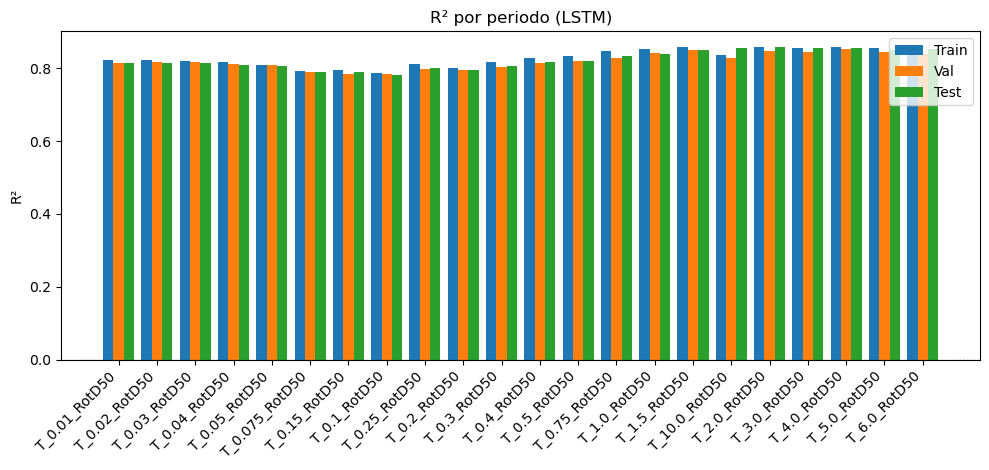

In [43]:
# ====== BLOQUE 4: Barras de R² por periodo (TRAIN / VAL / TEST) ======
import matplotlib.pyplot as plt

ys = np.array(df_test_metrics_lstm.index.tolist())
x = np.arange(len(ys)); w = 0.27

plt.figure(figsize=(10, 4.8))
plt.bar(x - w, df_train_metrics_lstm["R2"].values, width=w, label="Train")
plt.bar(x,      df_val_metrics_lstm["R2"].values,   width=w, label="Val")
plt.bar(x + w,  df_test_metrics_lstm["R2"].values,  width=w, label="Test")
plt.axhline(0.0, linestyle=":", linewidth=1)
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("R²"); plt.title("R² por periodo (LSTM)")
plt.legend(); plt.tight_layout(); plt.show()


### LSTM + Attention

In [44]:
# ========= Capa de Self-Attention con sesgo Colombia (region-aware boost) =========
class RegionAwareSelfAttention(layers.Layer):
    def __init__(self, d_model, n_heads=1, lambda_boost=0.2, **kwargs):
        super().__init__(**kwargs)
        assert d_model % n_heads == 0, "d_model debe ser divisible por n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.dk = d_model // n_heads
        self.lambda_boost = lambda_boost
        # Proyecciones Q, K, V
        self.Wq = layers.Dense(d_model, use_bias=False)
        self.Wk = layers.Dense(d_model, use_bias=False)
        self.Wv = layers.Dense(d_model, use_bias=False)
        self.out = layers.Dense(d_model, use_bias=False)

    def call(self, H, is_col):
        """
        H: [B, T, d_model] (salidas del LSTM proyectadas)
        is_col: [B, 1] escalar 0/1 (NGA/Colombia)
        """
        B = tf.shape(H)[0]
        T = tf.shape(H)[1]

        # === (1) Proyección Q,K,V ===
        Q = self.Wq(H)  # [B,T,d_model]
        K = self.Wk(H)
        V = self.Wv(H)

        # Split por cabezas: [B, n_heads, T, dk]
        def split_heads(X):
            X = tf.reshape(X, [B, T, self.n_heads, self.dk])
            return tf.transpose(X, [0, 2, 1, 3])

        Qh = split_heads(Q); Kh = split_heads(K); Vh = split_heads(V)

        # === (2) Logits de atención (scaled dot-product) ===
        logits = tf.matmul(Qh, Kh, transpose_b=True)  # [B, h, T, T]
        logits = logits / tf.math.sqrt(tf.cast(self.dk, tf.float32))

        # === (3) SESGO REGIONAL: boost si is_col = 1 ===
        #      (multiplicación por (1 + lambda * is_col) antes del softmax)
        boost = 1.0 + self.lambda_boost * is_col  # [B,1]
        boost = tf.reshape(boost, [B, 1, 1, 1])
        logits = logits * boost

        # === (4) Softmax para obtener pesos de atención ===
        A = tf.nn.softmax(logits, axis=-1)  # [B, h, T, T]

        # === (5) Aplicar pesos a V y recombinar cabezas ===
        H_att = tf.matmul(A, Vh)                          # [B,h,T,dk]
        H_att = tf.transpose(H_att, [0, 2, 1, 3])         # [B,T,h,dk]
        H_att = tf.reshape(H_att, [B, T, self.d_model])   # [B,T,d_model]
        return self.out(H_att), A  # regreso también A por si la quieres inspeccionar


In [45]:
# X_train, X_val, X_test son tus DataFrames originales
# Creamos una columna binaria: 1 = Colombia, 0 = otro (NGAW2)
iscol_tr = (X_train["origen"] == "Colombia").astype("float32").to_numpy().reshape(-1, 1)
iscol_va = (X_val["origen"]   == "Colombia").astype("float32").to_numpy().reshape(-1, 1)
iscol_te = (X_test["origen"]  == "Colombia").astype("float32").to_numpy().reshape(-1, 1)

print(iscol_tr.shape)  # (N_train, 1)


(7167, 1)


In [46]:
from tensorflow.keras import layers, Model, optimizers, callbacks, Input
import tensorflow as tf

# ----- Inputs -----
inp_seq = Input(shape=(n_features, 1), name="inp_seq")   # features RNN
inp_col = Input(shape=(1,), name="is_col")               # 0 = NGA, 1 = COL

# ===== Backbone compartido (LSTM + atención) =====
x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True),
        name="bilstm_seq"
    )(inp_seq)

x = layers.Dense(128, activation="linear", name="proj_for_attn")(x)

attn_layer = RegionAwareSelfAttention(
    d_model=128,
    n_heads=2,
    lambda_boost=0.0,     # puedes probar 0.0, 0.2, etc.
    name="region_self_attn"
)

x_att, attn_weights = attn_layer(x, inp_col)

x_ctx = layers.GlobalAveragePooling1D(name="attn_pooling")(x_att)
x_ctx = layers.Dense(64, activation="relu", name="shared_dense")(x_ctx)

# ===== Cabeza GLOBAL + corrección Colombia =====
# 1) Cabeza global: aprende el espectro promedio (NGA+COL)
out_global = layers.Dense(nT, activation=None, name="head_global")(x_ctx)

# 2) Cabeza de corrección SOLO para Colombia
out_delta_col = layers.Dense(
    nT,
    activation=None,
    kernel_regularizer=tf.keras.regularizers.l2(1e-2)
)(x_ctx)


# is_col: 0 = NGA, 1 = COL  -> expandimos a (B, nT)
w_col = inp_col                                   # (B,1)
w_col_t = tf.repeat(w_col, repeats=nT, axis=1)    # (B,nT)

# 3) Salida final:
#    - NGA:        y = out_global      (w_col=0)
#    - Colombia:   y = out_global + out_delta_col
out = out_global + w_col_t * out_delta_col

# ----- Definimos el modelo -----
modelLSTM_ATT_DeltaCol = Model(
    [inp_seq, inp_col],
    out,
    name="LSTM_Attn_Global_plus_DeltaCol"
)

modelLSTM_ATT_DeltaCol.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=masked_mse
)

modelLSTM_ATT_DeltaCol.summary()



Model: "LSTM_Attn_Global_plus_DeltaCol"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 inp_seq (InputLayer)        [(None, 10, 1)]              0         []                            
                                                                                                  
 bilstm_seq (Bidirectional)  (None, 10, 128)              33792     ['inp_seq[0][0]']             
                                                                                                  
 proj_for_attn (Dense)       (None, 10, 128)              16512     ['bilstm_seq[0][0]']          
                                                                                                  
 is_col (InputLayer)         [(None, 1)]                  0         []                            
                                                                     

In [47]:
history_delta = modelLSTM_ATT_DeltaCol.fit(
    [Xtr_rnn, iscol_tr], Ytr,
    validation_data=([Xva_rnn, iscol_va], Yva),
    epochs=400,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)


Epoch 1/400
112/112 [==============================] - 4s 15ms/step - loss: 6.0719 - val_loss: 2.9583 - lr: 0.0010
Epoch 2/400
112/112 [==============================] - 1s 9ms/step - loss: 2.8383 - val_loss: 2.6199 - lr: 0.0010
Epoch 3/400
112/112 [==============================] - 1s 9ms/step - loss: 2.3857 - val_loss: 1.8631 - lr: 0.0010
Epoch 4/400
112/112 [==============================] - 1s 9ms/step - loss: 1.8502 - val_loss: 1.5760 - lr: 0.0010
Epoch 5/400
112/112 [==============================] - 1s 9ms/step - loss: 1.3835 - val_loss: 0.9344 - lr: 0.0010
Epoch 6/400
112/112 [==============================] - 1s 9ms/step - loss: 0.9016 - val_loss: 0.7689 - lr: 0.0010
Epoch 7/400
112/112 [==============================] - 1s 9ms/step - loss: 0.7831 - val_loss: 0.8037 - lr: 0.0010
Epoch 8/400
112/112 [==============================] - 1s 9ms/step - loss: 0.7480 - val_loss: 0.6736 - lr: 0.0010
Epoch 9/400
112/112 [==============================] - 1s 9ms/step - loss: 0.7157 - val

In [48]:
"""# ejemplo de pesos por muestra
w_train = 1.0 + 7.0 * iscol_tr.squeeze()  # 1 para NGA, 8 para COL
history = modelLSTM_ATTN.fit(
    [Xtr_rnn, iscol_tr], Ytr,
    validation_data=([Xva_rnn, iscol_va], Yva),
    sample_weight=w_train,
    epochs=400, batch_size=64,
    callbacks=[es, rlr], verbose=1
)
"""

'# ejemplo de pesos por muestra\nw_train = 1.0 + 7.0 * iscol_tr.squeeze()  # 1 para NGA, 8 para COL\nhistory = modelLSTM_ATTN.fit(\n    [Xtr_rnn, iscol_tr], Ytr,\n    validation_data=([Xva_rnn, iscol_va], Yva),\n    sample_weight=w_train,\n    epochs=400, batch_size=64,\n    callbacks=[es, rlr], verbose=1\n)\n'

In [49]:
"""tf.keras.utils.set_random_seed(42)

# ---- INPUTS ----
inp_seq = Input(shape=(n_features, 1), name="inp_seq")   # tu entrada (timesteps=n_features, feat=1)
inp_col = Input(shape=(1,), name="is_col")               # escalar 0/1

# ---- BLOQUE LSTM (comentarios marcan cada paso) ----
# (A) BiLSTM que devuelve secuencia completa
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True), name="bilstm_seq")(inp_seq)
# (B) Proyección a d_model para la attention
x = layers.Dense(128, activation="linear", name="proj_for_attn")(x)

# === (C) SELF-ATTENTION REGION-AWARE (AQUÍ ESTÁ LA ATTENTION) ===
attn_layer = RegionAwareSelfAttention(d_model=128, n_heads=2, lambda_boost=0.2, name="region_self_attn")
x_att, attn_weights = attn_layer(x, inp_col)  # x_att: [B,T,128]

# (D) Pooling global sobre T (22 períodos) para obtener un vector resumen
x_ctx = layers.GlobalAveragePooling1D(name="attn_pooling")(x_att)  # [B,128]

# (E) Head densa -> vector multi-salida nT (igual que tu Dense final)
x_ctx = layers.Dense(64, activation="relu", name="head_dense")(x_ctx)
out = layers.Dense(nT, activation=None, name="head_out")(x_ctx)

modelLSTM_ATTN = Model([inp_seq, inp_col], out, name="LSTM_Attn_RegionAware")
modelLSTM_ATTN.compile(optimizer=optimizers.Adam(1e-3), loss=masked_mse)

# ---- Callbacks ----
es  = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6)

# ---- Entrenamiento (ojo: ahora pasas 2 inputs) ----
history = modelLSTM_ATTN.fit(
    [Xtr_rnn, iscol_tr], Ytr,
    validation_data=([Xva_rnn, iscol_va], Yva),
    epochs=400, batch_size=64,
    callbacks=[es, rlr], verbose=1
)

print("Test loss:", modelLSTM_ATTN.evaluate([Xte_rnn, iscol_te], Yte, verbose=0))
y_pred_test = modelLSTM_ATTN.predict([Xte_rnn, iscol_te]) """

'tf.keras.utils.set_random_seed(42)\n\n# ---- INPUTS ----\ninp_seq = Input(shape=(n_features, 1), name="inp_seq")   # tu entrada (timesteps=n_features, feat=1)\ninp_col = Input(shape=(1,), name="is_col")               # escalar 0/1\n\n# ---- BLOQUE LSTM (comentarios marcan cada paso) ----\n# (A) BiLSTM que devuelve secuencia completa\nx = layers.Bidirectional(layers.LSTM(64, return_sequences=True), name="bilstm_seq")(inp_seq)\n# (B) Proyección a d_model para la attention\nx = layers.Dense(128, activation="linear", name="proj_for_attn")(x)\n\n# === (C) SELF-ATTENTION REGION-AWARE (AQUÍ ESTÁ LA ATTENTION) ===\nattn_layer = RegionAwareSelfAttention(d_model=128, n_heads=2, lambda_boost=0.2, name="region_self_attn")\nx_att, attn_weights = attn_layer(x, inp_col)  # x_att: [B,T,128]\n\n# (D) Pooling global sobre T (22 períodos) para obtener un vector resumen\nx_ctx = layers.GlobalAveragePooling1D(name="attn_pooling")(x_att)  # [B,128]\n\n# (E) Head densa -> vector multi-salida nT (igual que t

In [50]:
# ====== BLOQUE 1: Predicciones y nombres de salida (LSTM+ATT) ======

# Predicciones del modelo con attention
y_pred_train_att = modelLSTM_ATT_DeltaCol.predict([Xtr_rnn, iscol_tr], verbose=0)
y_pred_val_att   = modelLSTM_ATT_DeltaCol.predict([Xva_rnn, iscol_va], verbose=0)
y_pred_test_att  = modelLSTM_ATT_DeltaCol.predict([Xte_rnn, iscol_te], verbose=0)

# Nombres de las salidas (por periodo)
# Si tienes un índice/serie Sa_Crustal con los nombres de las columnas:
y_names = list(Sa_Crustal) if 'Sa_Crustal' in globals() else [f"Y_{j}" for j in range(Yte.shape[1])]
if len(y_names) != Yte.shape[1]:
    y_names = [f"Y_{j}" for j in range(Yte.shape[1])]

# Si entrenaste en log(Sa), puedes volver a escala original para las métricas
EXP_BACKTRANS = False  # pon True si tus Y están en log

Y_tr_eval  = np.exp(Ytr)            if EXP_BACKTRANS else Ytr
Y_va_eval  = np.exp(Yva)            if EXP_BACKTRANS else Yva
Y_te_eval  = np.exp(Yte)            if EXP_BACKTRANS else Yte
Yp_tr_eval = np.exp(y_pred_train_att) if EXP_BACKTRANS else y_pred_train_att
Yp_va_eval = np.exp(y_pred_val_att)   if EXP_BACKTRANS else y_pred_val_att
Yp_te_eval = np.exp(y_pred_test_att)  if EXP_BACKTRANS else y_pred_test_att



In [51]:
# ====== BLOQUE 2: Función auxiliar y 3 DataFrames (LSTM+ATT) ======
import pandas as pd
import numpy as np

def _metrics_df(Y_true, Y_pred, names):
    rows = []
    for j, name in enumerate(names):
        y_t = Y_true[:, j]
        y_p = Y_pred[:, j]
        # Máscara de valores finitos (por si hay NaNs) 
        m = np.isfinite(y_t) & np.isfinite(y_p)
        if m.sum() == 0:
            rows.append({
                "Y": name, "RMSE": np.nan, "MSE": np.nan,
                "MAE": np.nan, "MAPE_%": np.nan, "R2": np.nan
            })
            continue

        err  = y_p[m] - y_t[m]
        mse  = np.mean(err**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(err))

        # MAPE evitando dividir por ~0
        mm   = (np.abs(y_t) > 1e-12) & m
        if mm.sum():
            mape = np.mean(np.abs((y_p[mm] - y_t[mm]) / y_t[mm])) * 100.0
        else:
            mape = np.nan

        y_mean = np.mean(y_t[m])
        ss_res = np.sum((y_t[m] - y_p[m])**2)
        ss_tot = np.sum((y_t[m] - y_mean)**2)
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)

        rows.append({
            "Y": name,
            "RMSE": rmse, "MSE": mse, "MAE": mae,
            "MAPE_%": mape, "R2": r2
        })

    return pd.DataFrame(rows).set_index("Y").sort_index()

# DataFrames de métricas para el modelo LSTM+Attention
df_train_metrics_att = _metrics_df(Y_tr_eval, Yp_tr_eval, y_names)
df_val_metrics_att   = _metrics_df(Y_va_eval, Yp_va_eval, y_names)
df_test_metrics_att  = _metrics_df(Y_te_eval, Yp_te_eval, y_names)

df_test_metrics_att  # para ver rápido el de TEST




,RMSE,MSE,MAE,MAPE_%,R2
Y,,,,,
T_0.01_RotD50,0.701579,0.492213,0.546130,18.279018,0.826916
T_0.02_RotD50,0.705710,0.498026,0.547835,18.224795,0.825527
T_0.03_RotD50,0.711373,0.506051,0.552546,18.349029,0.824123
T_0.04_RotD50,0.716439,0.513285,0.558900,21.832637,0.822516
T_0.05_RotD50,0.721434,0.520467,0.563018,22.211139,0.821906
T_0.075_RotD50,0.763408,0.582791,0.595880,29.413974,0.803791
T_0.15_RotD50,0.769971,0.592855,0.600024,40.986431,0.799429
T_0.1_RotD50,0.778457,0.605995,0.607961,36.128983,0.796129
T_0.25_RotD50,0.754794,0.569713,0.598124,50.949061,0.808618


En general el LSTM+ATT sí mejora al LSTM, pero el salto es moderado: casi en todos los periodos bajan ligeramente el RMSE/MSE/MAE (por ejemplo en T=0.01–0.05 la RMSE pasa de ~0.72–0.75 a ~0.70–0.72) y el R² sube unos puntos (típicamente de 0.81–0.85 a 0.82–0.87). 

El MAPE también mejora en la mayoría de periodos, sobre todo en los más conflictivos: T=0.075, 0.1, 0.15, 0.3, 0.5, 0.75, 1.0, 1.5, 2–10 s (ej. en T=0.3 baja de 46.5% a 40.8% y en 10 s de 9.16% a 8.35%), aunque hay un par de puntos donde queda prácticamente igual o un poco peor (0.04, 0.25, 0.4 s). 

En resumen: el modelo con atención es un refinamiento consistente del LSTM

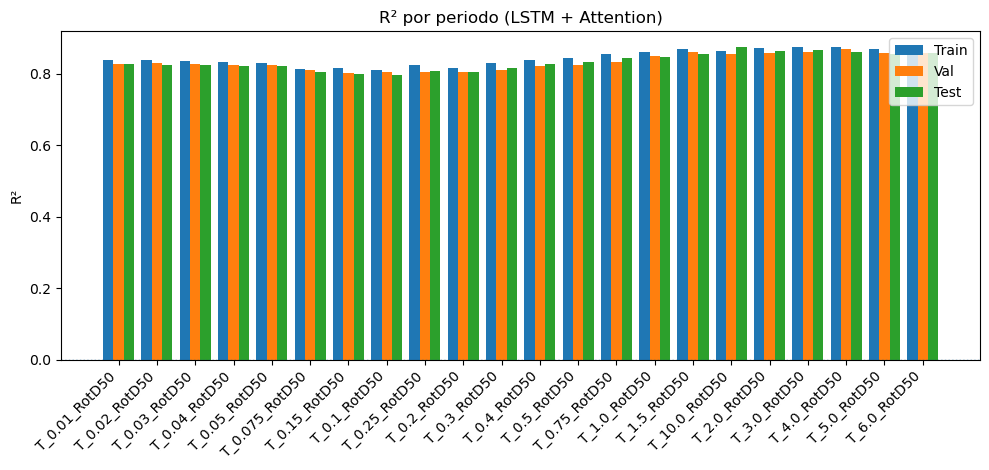

In [52]:
# ====== BLOQUE 3: Barras R² por periodo (LSTM+ATT) ======
import matplotlib.pyplot as plt
import numpy as np

ys = np.array(df_test_metrics_att.index.tolist())
x = np.arange(len(ys))
w = 0.27

plt.figure(figsize=(10, 4.8))
plt.bar(x - w, df_train_metrics_att["R2"].values, width=w, label="Train")
plt.bar(x,      df_val_metrics_att["R2"].values,   width=w, label="Val")
plt.bar(x + w,  df_test_metrics_att["R2"].values,  width=w, label="Test")

plt.axhline(0.0, linestyle=":", linewidth=1)
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("R²")
plt.title("R² por periodo (LSTM + Attention)")
plt.legend()
plt.tight_layout()
plt.show()


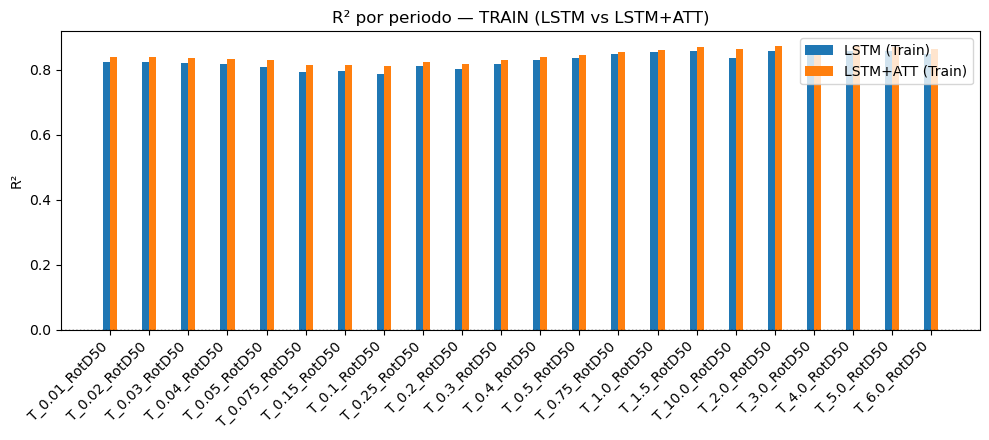

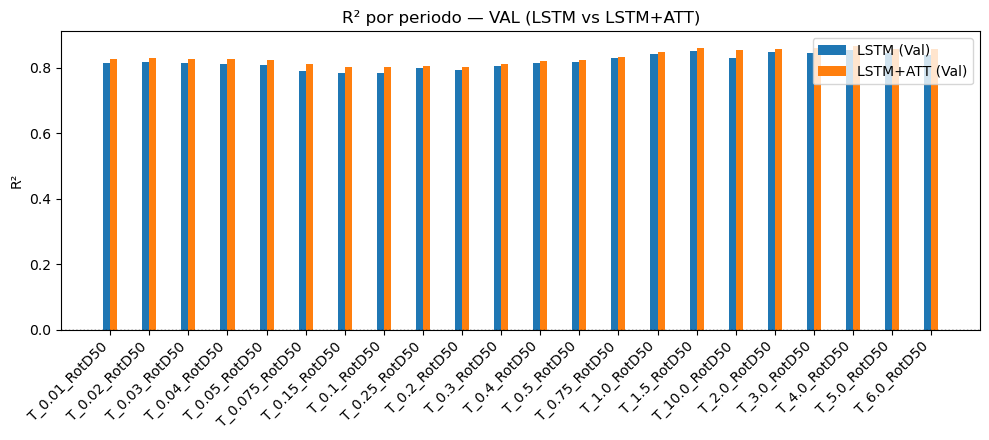

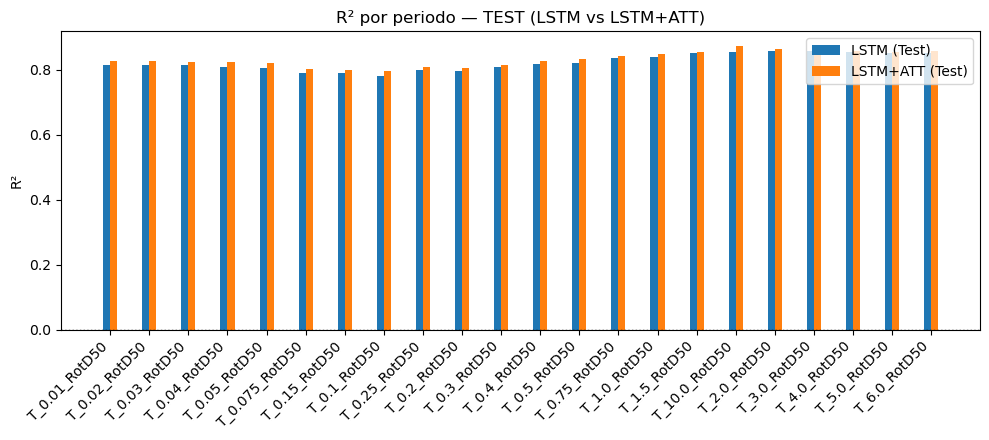

In [53]:
# ====== BLOQUE A: Comparación LSTM vs LSTM+ATT en R² por periodo ======
import numpy as np
import matplotlib.pyplot as plt

# Asegurarnos de usar el mismo orden de periodos
ys = np.array(df_test_metrics_lstm.index.tolist())
x = np.arange(len(ys))
w = 0.18  # ancho de barra

# --- 1) TRAIN ---
plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, df_train_metrics_lstm["R2"].values, width=w, label="LSTM (Train)")
plt.bar(x + w/2, df_train_metrics_att["R2"].values,  width=w, label="LSTM+ATT (Train)")
plt.axhline(0.0, linestyle=":", linewidth=1, color="black")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("R²")
plt.title("R² por periodo — TRAIN (LSTM vs LSTM+ATT)")
plt.legend()
plt.tight_layout()
plt.show()

# --- 2) VAL ---
plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, df_val_metrics_lstm["R2"].values, width=w, label="LSTM (Val)")
plt.bar(x + w/2, df_val_metrics_att["R2"].values,  width=w, label="LSTM+ATT (Val)")
plt.axhline(0.0, linestyle=":", linewidth=1, color="black")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("R²")
plt.title("R² por periodo — VAL (LSTM vs LSTM+ATT)")
plt.legend()
plt.tight_layout()
plt.show()

# --- 3) TEST ---
plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, df_test_metrics_lstm["R2"].values, width=w, label="LSTM (Test)")
plt.bar(x + w/2, df_test_metrics_att["R2"].values,  width=w, label="LSTM+ATT (Test)")
plt.axhline(0.0, linestyle=":", linewidth=1, color="black")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("R²")
plt.title("R² por periodo — TEST (LSTM vs LSTM+ATT)")
plt.legend()
plt.tight_layout()
plt.show()

Gráficamente se puede evidenciar como las métricas aumentan usando el conjunto de test para ambos modelos, lo que sugiere que el modelo aprende mejor sobre las formas en general.

## Métricas para evaluar el desempeño por conjuntos de origen

In [54]:
# ====== BLOQUE 1: Unir todo y preparar arrays (LSTM+ATT) ======
import numpy as np

# Y_true (los mismos que usaste para métricas, en la escala que quieras)
# Si quieres trabajar en log(Sa), usa directamente Ytr, Yva, Yte
# Si quieres trabajar en Sa, usa Y_tr_eval, etc. (del bloque anterior)
Y_all_true = np.vstack([Y_tr_eval, Y_va_eval, Y_te_eval])           # [N_total, nT]
Y_all_pred = np.vstack([Yp_tr_eval, Yp_va_eval, Yp_te_eval])        # [N_total, nT]

# Unir también el indicador de Colombia (iscol_tr/va/te vienen del DataFrame original)
iscol_all = np.vstack([iscol_tr, iscol_va, iscol_te]).reshape(-1,)  # [N_total,]
iscol_all = iscol_all.astype(bool)

print(Y_all_true.shape, Y_all_pred.shape, iscol_all.shape)


(10239, 22) (10239, 22) (10239,)


In [55]:
# ====== BLOQUE 2: Std de residuales por periodo (total vs Colombia) ======
std_total = []
std_col   = []

for j in range(Y_all_true.shape[1]):
    y_t = Y_all_true[:, j]
    y_p = Y_all_pred[:, j]
    m = np.isfinite(y_t) & np.isfinite(y_p)

    # residuales
    resid = y_p[m] - y_t[m]

    # conjunto completo
    std_total.append(np.std(resid))

    # subconjunto colombiano
    m_col = m & iscol_all
    if m_col.sum() > 0:
        std_col.append(np.std(y_p[m_col] - y_t[m_col]))
    else:
        std_col.append(np.nan)

std_total = np.array(std_total)
std_col   = np.array(std_col)


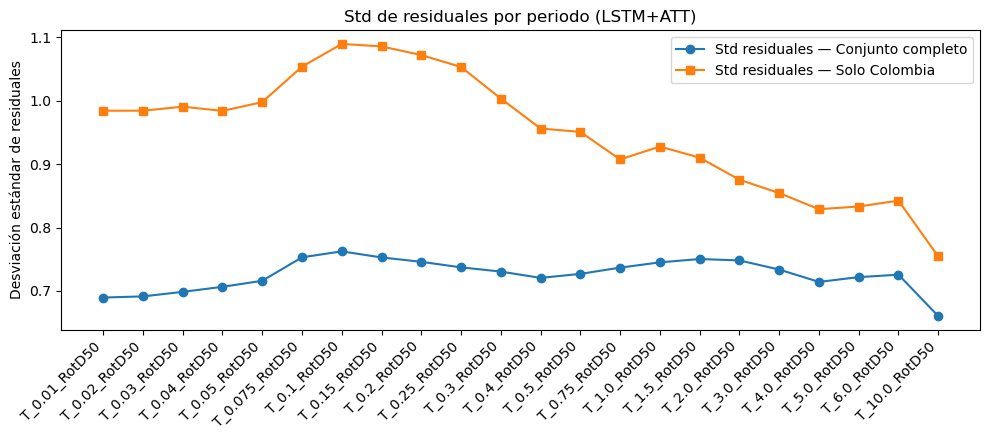

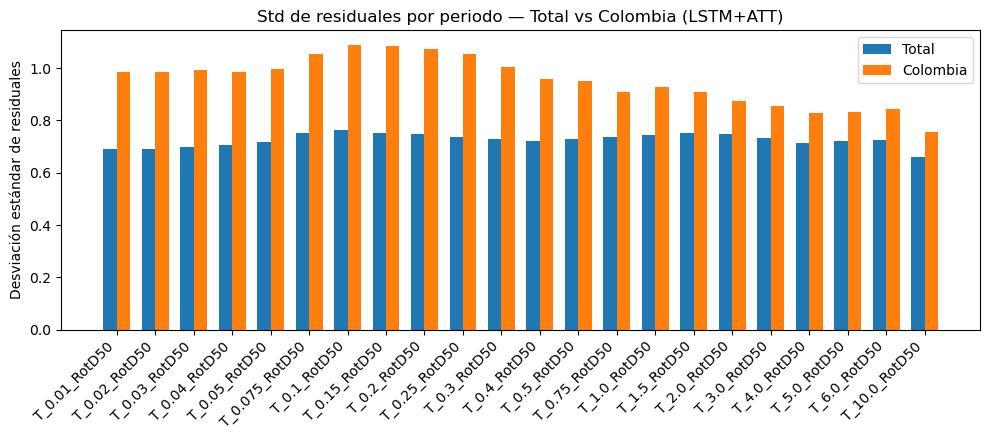

In [56]:
# ====== BLOQUE 3: Plots de desviación estándar por periodo ======
import matplotlib.pyplot as plt

ys = np.array(y_names)
x = np.arange(len(ys))

# --- Plot 1: Curvas total vs Colombia ---
plt.figure(figsize=(10, 4.5))
plt.plot(x, std_total, marker="o", label="Std residuales — Conjunto completo")
plt.plot(x, std_col,   marker="s", label="Std residuales — Solo Colombia")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("Desviación estándar de residuales")
plt.title("Std de residuales por periodo (LSTM+ATT)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Barras lado a lado ---
w = 0.35
plt.figure(figsize=(10, 4.5))
plt.bar(x - w/2, std_total, width=w, label="Total")
plt.bar(x + w/2, std_col,   width=w, label="Colombia")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("Desviación estándar de residuales")
plt.title("Std de residuales por periodo — Total vs Colombia (LSTM+ATT)")
plt.legend()
plt.tight_layout()
plt.show()


## Otra

In [57]:
import numpy as np

# ====== BLOQUE 1: Backtransform (si aplica) y unión de splits ======

# 1) Verdaderos (misma lógica que antes)
# Si trabajas en log(Sa), EXP_BACKTRANS=False → trabajas directamente con Ytr,Yva,Yte
# Si tus métricas las vienes calculando en Sa, pon EXP_BACKTRANS=True y usa exp()
EXP_BACKTRANS = False  # o True, como lo estés manejando

Y_tr_eval  = np.exp(Ytr) if EXP_BACKTRANS else Ytr
Y_va_eval  = np.exp(Yva) if EXP_BACKTRANS else Yva
Y_te_eval  = np.exp(Yte) if EXP_BACKTRANS else Yte

# 2) Predicciones LSTM (sin attention)
Yp_tr_lstm_eval = np.exp(y_pred_train) if EXP_BACKTRANS else y_pred_train
Yp_va_lstm_eval = np.exp(y_pred_val)   if EXP_BACKTRANS else y_pred_val
Yp_te_lstm_eval = np.exp(y_pred_test)  if EXP_BACKTRANS else y_pred_test

# 3) Predicciones LSTM+ATT (ya las calculaste como y_pred_*_att)
Yp_tr_att_eval = np.exp(y_pred_train_att) if EXP_BACKTRANS else y_pred_train_att
Yp_va_att_eval = np.exp(y_pred_val_att)   if EXP_BACKTRANS else y_pred_val_att
Yp_te_att_eval = np.exp(y_pred_test_att)  if EXP_BACKTRANS else y_pred_test_att

# 4) Unir todo (Train+Val+Test) para cada modelo
Y_all_true      = np.vstack([Y_tr_eval,      Y_va_eval,      Y_te_eval])
Y_all_pred_lstm = np.vstack([Yp_tr_lstm_eval, Yp_va_lstm_eval, Yp_te_lstm_eval])
Y_all_pred_att  = np.vstack([Yp_tr_att_eval,  Yp_va_att_eval,  Yp_te_att_eval])

# 5) Unir indicador de Colombia (0/1 → bool)
iscol_all = np.vstack([iscol_tr, iscol_va, iscol_te]).reshape(-1,).astype(bool)

print("Y_all_true:", Y_all_true.shape)
print("Y_all_pred_lstm:", Y_all_pred_lstm.shape)
print("Y_all_pred_att:",  Y_all_pred_att.shape)
print("iscol_all:", iscol_all.shape)


Y_all_true: (10239, 22)
Y_all_pred_lstm: (10239, 22)
Y_all_pred_att: (10239, 22)
iscol_all: (10239,)


In [58]:
# ====== BLOQUE 2: Std residuales por periodo (LSTM vs LSTM+ATT) ======

nT = Y_all_true.shape[1]

std_total_lstm = []
std_col_lstm   = []
std_total_att  = []
std_col_att    = []

for j in range(nT):
    # Valores verdaderos y predichos para el periodo j
    y_t  = Y_all_true[:, j]
    y_pl = Y_all_pred_lstm[:, j]
    y_pa = Y_all_pred_att[:, j]

    # Máscara de finitos
    m_l = np.isfinite(y_t) & np.isfinite(y_pl)
    m_a = np.isfinite(y_t) & np.isfinite(y_pa)

    # Residuales
    resid_l = y_pl[m_l] - y_t[m_l]
    resid_a = y_pa[m_a] - y_t[m_a]

    # --- total ---
    std_total_lstm.append(np.std(resid_l) if resid_l.size > 0 else np.nan)
    std_total_att.append(np.std(resid_a) if resid_a.size > 0 else np.nan)

    # --- Colombia ---
    m_col_l = m_l & iscol_all
    m_col_a = m_a & iscol_all

    if m_col_l.sum() > 0:
        std_col_lstm.append(np.std(y_pl[m_col_l] - y_t[m_col_l]))
    else:
        std_col_lstm.append(np.nan)

    if m_col_a.sum() > 0:
        std_col_att.append(np.std(y_pa[m_col_a] - y_t[m_col_a]))
    else:
        std_col_att.append(np.nan)

std_total_lstm = np.array(std_total_lstm)
std_col_lstm   = np.array(std_col_lstm)
std_total_att  = np.array(std_total_att)
std_col_att    = np.array(std_col_att)


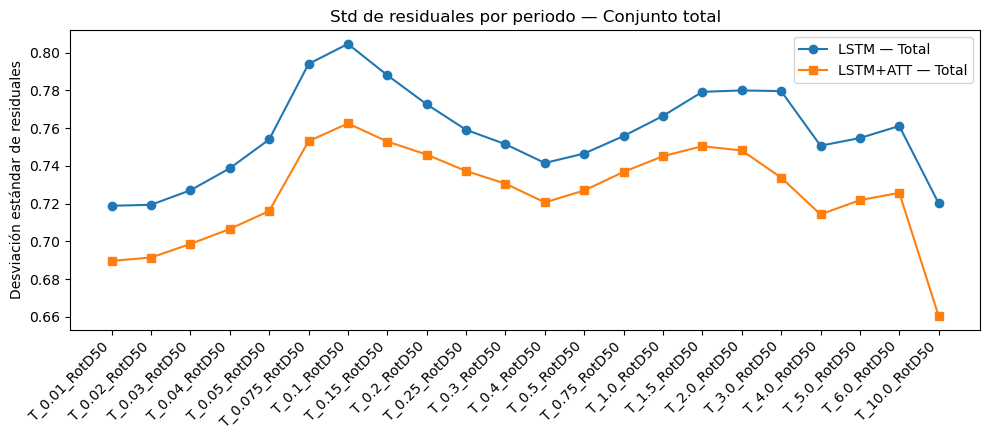

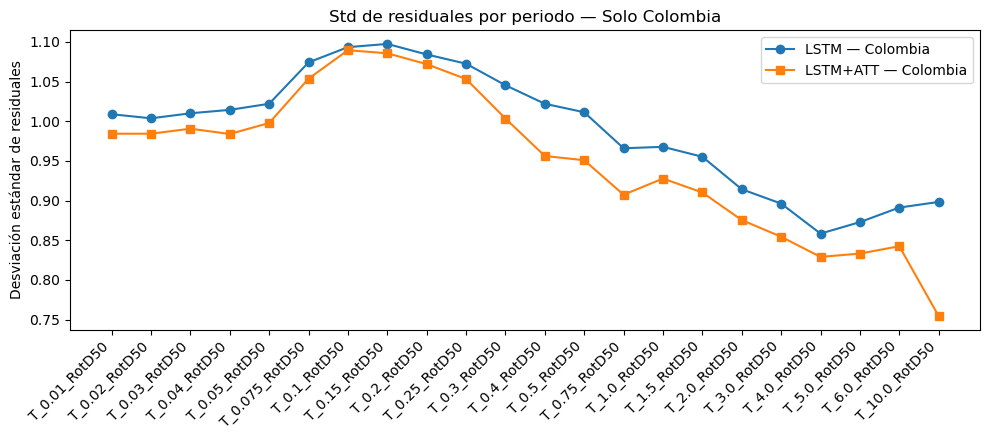

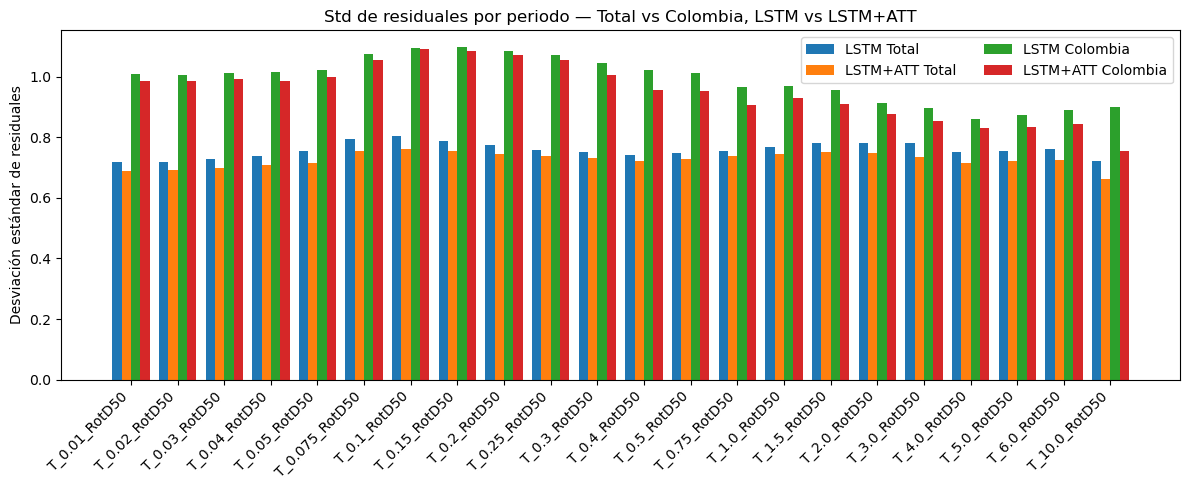

In [59]:
# ====== BLOQUE 3: Gráficos de comparación de desviaciones ======
import matplotlib.pyplot as plt
import numpy as np

# Asumimos que ya tienes y_names (nombres de cada periodo/columna)
ys = np.array(y_names)
x = np.arange(len(ys))

# --- 1) Std total: LSTM vs LSTM+ATT ---
plt.figure(figsize=(10, 4.5))
plt.plot(x, std_total_lstm, marker="o", label="LSTM — Total")
plt.plot(x, std_total_att,  marker="s", label="LSTM+ATT — Total")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("Desviación estándar de residuales")
plt.title("Std de residuales por periodo — Conjunto total")
plt.legend()
plt.tight_layout()
plt.show()

# --- 2) Std solo Colombia: LSTM vs LSTM+ATT ---
plt.figure(figsize=(10, 4.5))
plt.plot(x, std_col_lstm, marker="o", label="LSTM — Colombia")
plt.plot(x, std_col_att,  marker="s", label="LSTM+ATT — Colombia")
plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("Desviación estándar de residuales")
plt.title("Std de residuales por periodo — Solo Colombia")
plt.legend()
plt.tight_layout()
plt.show()

# --- 3) (Opcional) Barras con las 4 curvas a la vez ---
w = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w, std_total_lstm, width=w, label="LSTM Total")
plt.bar(x - 0.5*w, std_total_att,  width=w, label="LSTM+ATT Total")
plt.bar(x + 0.5*w, std_col_lstm,   width=w, label="LSTM Colombia")
plt.bar(x + 1.5*w, std_col_att,    width=w, label="LSTM+ATT Colombia")

plt.xticks(x, ys, rotation=45, ha="right")
plt.ylabel("Desviación estándar de residuales")
plt.title("Std de residuales por periodo — Total vs Colombia, LSTM vs LSTM+ATT")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Ciertamente también es importante comparar como se comporta la desviación estándar para el caso de los registros colombianos ya que la idea inicial es que se ajuste mejor a este conjunto. 

Se logra evidenciar como disminuye en comparación con lo hecho con el modelo base de LSTM 

#### NO HACE PARTE DEL PROYECTO.

In [70]:
# Magnitudes que quieres probar
mags = [4.5, 5.5, 6.5, 7.5]

# Valores fijos
RRUP_FIX  = np.log(100)
SOIL_FIX  = "3"        # ajústalo si tu codificación de suelos es otra
ZHYPO_FIX = 10.0

# Si tus modelos predicen ln(Sa), pon True para graficar Sa
EXP_BACKTRANS = False   # o True si entrenaste en log(Sa)

# ==== Periodos T (a partir de los nombres de salida) ====
if 'Sa_Crustal' in globals():
    y_names = list(Sa_Crustal)
else:
    y_names = [f"T_{j}" for j in range(Ytr.shape[1])]

def _parse_T(name):
    try:
        s = str(name)
        if "T_" in s:
            s = s.split("T_")[1]
        if "_" in s:
            s = s.split("_")[0]
        return float(s)
    except Exception:
        return np.nan

T_vals = np.array([_parse_T(n) for n in y_names])
if np.isnan(T_vals).all():
    T_vals = np.arange(len(y_names))


In [71]:
# ==== Nombres de columnas en X_train ====
ORIGIN_COL = "origen"                # <--- cámbialo si se llama distinto
MW_COL     = "Magnitude"             # <--- ajusta a tu DF
RRUP_COL   = "Rrup_OpenQuake"        # <--- ajusta
ZHYPO_COL  = "Hypocenter Depth (km)" # <--- ajusta
SOIL_COL   = "Soil_Class"            # <--- ajusta

def build_input_for_Mw(Mw_value):
    """
    Toma una fila base de X_train, la fuerza a ser de Colombia y
    cambia Mw, Rrup, Zhypo y Soil. Luego la pasa por `pre`.
    """
    # Fila base (la 0, por ejemplo)
    x0 = X_train.iloc[[0]].copy()

    # Forzar origen = Colombia respetando tipo (número o string)

    x0[ORIGIN_COL] = "Colombia"
    # Actualizar las demás variables
    x0[MW_COL]    = Mw_value
    x0[RRUP_COL]  = RRUP_FIX
    x0[ZHYPO_COL] = ZHYPO_FIX
    x0[SOIL_COL]  = SOIL_FIX
    print(x0)
    # Pasar por el preprocesador
    X_feats = pre.transform(x0)           # (1, n_features)
    n_features = X_feats.shape[1]
    X_rnn = X_feats.reshape(1, n_features, 1)
    print(X_feats)
    # Para el modelo con attention: is_col = 1 siempre (porque forzamos Colombia)
    iscol = np.array([[1.0]], dtype="float32")

    return X_rnn, iscol


In [72]:
preds_lstm = {}
preds_att  = {}

for Mw in mags:
    X_rnn, iscol = build_input_for_Mw(Mw)

    y_lstm = modelLSTM.predict(X_rnn, verbose=0)[0]             # (nT,)
    y_att  = modelLSTM_ATT_DeltaCol.predict([X_rnn, iscol], verbose=0)[0]

    if EXP_BACKTRANS:
        y_lstm = np.exp(y_lstm)
        y_att  = np.exp(y_att)

    preds_lstm[Mw] = y_lstm
    preds_att[Mw]  = y_att


      Magnitude  Rrup_OpenQuake  Hypocenter Depth (km) Soil_Class    origen
6237        4.5         4.60517                   10.0          3  Colombia
[[-1.24011062  0.38418225 -0.12893549  0.          0.          1.
   0.          0.          1.          0.        ]]
      Magnitude  Rrup_OpenQuake  Hypocenter Depth (km) Soil_Class    origen
6237        5.5         4.60517                   10.0          3  Colombia
[[-0.36199386  0.38418225 -0.12893549  0.          0.          1.
   0.          0.          1.          0.        ]]
      Magnitude  Rrup_OpenQuake  Hypocenter Depth (km) Soil_Class    origen
6237        6.5         4.60517                   10.0          3  Colombia
[[ 0.5161229   0.38418225 -0.12893549  0.          0.          1.
   0.          0.          1.          0.        ]]
      Magnitude  Rrup_OpenQuake  Hypocenter Depth (km) Soil_Class    origen
6237        7.5         4.60517                   10.0          3  Colombia
[[ 1.39423966  0.38418225 -0.12893549 

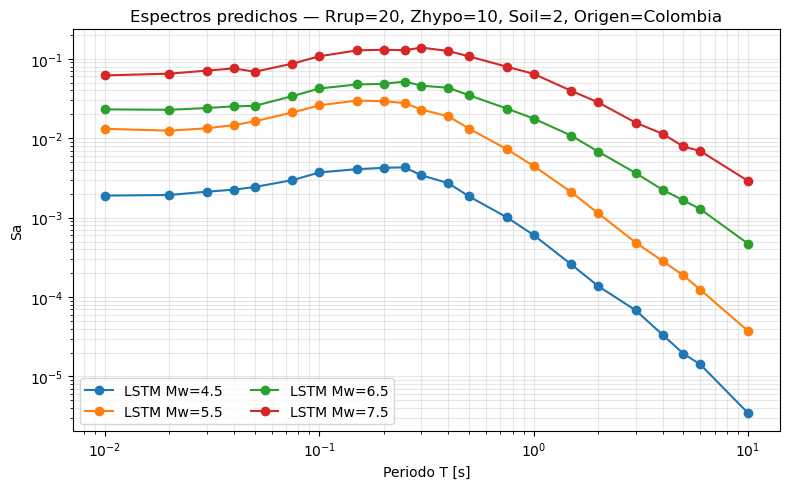

In [73]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

for Mw in mags:
    # LSTM (línea continua)
    ax.plot(
        T_vals,
        np.exp(preds_lstm[Mw]),
        linestyle="-",
        marker="o",
        label=f"LSTM Mw={Mw}"
    )

     # LSTM+ATT (línea discontinua)
    """ax.plot(
        T_vals,
        np.exp(preds_att[Mw]),
        linestyle="--",
        marker="s",
        label=f"LSTM+ATT Mw={Mw}"
    )"""

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Periodo T [s]")
ax.set_ylabel("Sa")
ax.set_title("Espectros predichos — Rrup=20, Zhypo=10, Soil=2, Origen=Colombia")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


h

## GMM

In [64]:
from NoSAm_GMMs_2024 import *

In [65]:
from openquake.hazardlib import const, contexts, gsim, imt
from openquake.hazardlib.imt import PGV, PGA, SA, RSD575, RSD595, IA, CAV
from openquake.hazardlib.contexts import RuptureContext, SitesContext, DistancesContext
from openquake.hazardlib.gsim.abrahamson_2014 import AbrahamsonEtAl2014 as ASK14

In [66]:
periodos1 = [float(item.split('_')[1]) for item in Sa_Crustal]


nosam = []
for t in periodos1:
    val = NoSAm_Crustal_2023(t, 4.5, np.exp(RRUP_FIX), int(SOIL_FIX), 'average', ZHYPO_FIX, 0)
    nosam.append(val)
p1 = []
for i in range(len(nosam)):
    p1.append(nosam[i][0])
nosam = []
for t in periodos1:
    val = NoSAm_Crustal_2023(t, 5.5, np.exp(RRUP_FIX), int(SOIL_FIX), 'average', ZHYPO_FIX, 0)
    nosam.append(val)
p2 = []
for i in range(len(nosam)):
    p2.append(nosam[i][0])
nosam = []
for t in periodos1:
    val = NoSAm_Crustal_2023(t, 6.5, np.exp(RRUP_FIX), int(SOIL_FIX), 'average', ZHYPO_FIX, 0)
    nosam.append(val)
p3 = []
for i in range(len(nosam)):
    p3.append(nosam[i][0])
nosam = []
for t in periodos1:
    val = NoSAm_Crustal_2023(t, 7.5, np.exp(RRUP_FIX), int(SOIL_FIX), 'average', ZHYPO_FIX, 0)
    nosam.append(val)
p4 = []
for i in range(len(nosam)):
    p4.append(nosam[i][0])
p=[p1, p2, p3, p4]

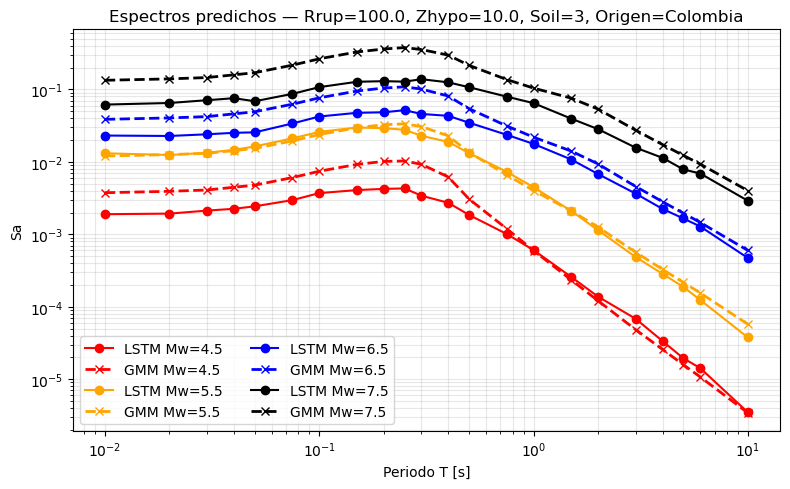

In [67]:
import matplotlib.pyplot as plt
import numpy as np
a = 0
fig, ax = plt.subplots(figsize=(8, 5))
colors      = ['red', 'orange', 'blue', 'black']
for Mw in mags:
    # LSTM (línea continua)
    ax.plot(
        T_vals,
        np.exp(preds_lstm[Mw]),
        linestyle="-",
        marker="o",
        label=f"LSTM Mw={Mw}", color=colors[a]
    )

     # LSTM+ATT (línea discontinua)
    """ax.plot(
        T_vals,
        np.exp(preds_att[Mw]),
        linestyle="--",
        marker="s",
        label=f"LSTM+ATT Mw={Mw}"
    )"""
    ax.plot(T_vals, p[a],
            label=f'GMM Mw={Mw}', color=colors[a],
            linestyle='--', marker='x', linewidth=2)
    a=a+1
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Periodo T [s]")
ax.set_ylabel("Sa")
ax.set_title(f"Espectros predichos — Rrup={np.round(np.exp(RRUP_FIX))}, Zhypo={ZHYPO_FIX}, Soil={SOIL_FIX}, Origen=Colombia")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

In [68]:
def calculate_z1pt0(vs30):
    '''
    Reads an array of vs30 values (in m/s) and
    returns the depth to the 1.0 km/s velocity horizon (in m)
    Ref: Chiou & Youngs (2014) California model
    :param vs30: the shear wave velocity (in m/s) at a depth of 30m
    '''
    c1 = 571 ** 4.
    c2 = 1360.0 ** 4.
    return np.exp((-7.15 / 4.0) * np.log((vs30 ** 4. + c1) / (c2 + c1)))


def calculate_z2pt5_ngaw2(vs30):
    '''
    Reads an array of vs30 values (in m/s) and
    returns the depth to the 2.5 km/s velocity horizon (in km)
    Ref: Campbell, K.W. & Bozorgnia, Y., 2014.
    'NGA-West2 ground motion model for the average horizontal components of
    PGA, PGV, and 5pct damped linear acceleration response spectra.'
    Earthquake Spectra, 30(3), pp.1087–1114.

    :param vs30: the shear wave velocity (in m/s) at a depth of 30 m
    '''
    c1 = 7.089
    c2 = -1.144
    z2pt5 = np.exp(c1 + np.log(vs30) * c2)
    return z2pt5

def estimate_width_ASK14(dip, mag):  
    """
    Estimate the fault rupture width using the ASK14 model.
    This is based on the NGA-West 2 GMM implementation.

    Parameters
    ----------
    dip : array-like
        Dip angle of the fault in degrees. Should be a 1D array or Series of floats.
    mag : array-like
        Magnitude of the earthquake. Should be a 1D array or Series of floats.

    Returns
    -------
    np.ndarray
        Estimated rupture width for each (dip, mag) pair.
    """
    return np.minimum(18 / np.sin(np.radians(dip)), 10 ** (-1.75 + 0.45 * mag))

def ASK14_GMM_test(Periods_pSA, Mag, Rrup, Zhypo, Vs30_Val, 
                   dip = 90.0, rake = -15.03):
    pSA_IMs_OQ = [SA(el) for el in Periods_pSA]
    
    rup_ctx = RuptureContext()
    rup_ctx.mag = Mag
    rup_ctx.width = estimate_width_ASK14(dip, Mag)
    rup_ctx.ztor = 0.0
    rup_ctx.hypo_depth = Zhypo
    rup_ctx.rake = rake
    rup_ctx.dip = dip

    site_ctx = SitesContext()
    site_ctx.vs30 = Vs30_Val
    site_ctx.vs30measured = False
    site_ctx.z1pt0 = calculate_z1pt0(Vs30_Val)
    site_ctx.z2pt5 = calculate_z2pt5_ngaw2(Vs30_Val)
    site_ctx.sids = [0]
    site_ctx.backarc = False

    dist_ctx = DistancesContext()
    dist_ctx.rhypo = Rrup
    dist_ctx.rrup = Rrup
    dist_ctx.rjb = Rrup
    dist_ctx.repi = Rrup
    dist_ctx.rx = 0.0
    dist_ctx.ry0 = 0.0

    mean_ASK14 = []
    sigma_ASK14 = []
    for IM_int in pSA_IMs_OQ:
        mean, sigma = ASK14().get_mean_and_stddevs(site_ctx, rup_ctx, dist_ctx, imt = IM_int, stddev_types=['Total'])
        print(f"IM: {IM_int}, Mean: {mean}, Sigma: {sigma}")
    
        mean_ASK14.append(np.exp(mean[0]))
        sigma_ASK14.append(sigma[0])

    return mean_ASK14, sigma_ASK14


In [69]:
Mw_list = [4.5, 5.5, 6.5, 7.5]

if int(SOIL_FIX) == 1:
    Vs30_Val = 1600
elif int(SOIL_FIX) == 2: 
    Vs30_Val = 800
elif int(SOIL_FIX) == 3:
    Vs30_Val = 450
elif int(SOIL_FIX) == 4:
    Vs30_Val = 250
elif int(SOIL_FIX) == 5:
    Vs30_Val = 100


pred_mat = []

for Mw in [4.5, 5.5, 6.5, 7.5]:
    Sa_mu_sigma = ASK14_GMM_test(               
        T_vals,                           
        Mag   = Mw,
        Rrup  = np.exp(RRUP_FIX),                            
        Zhypo = np.exp(ZHYPO_FIX),
        Vs30_Val = Vs30_Val
    )
    Sa_mu = Sa_mu_sigma[0]                  
    pred_mat.append(Sa_mu)

pred_mat = np.vstack(pred_mat)     

IM: SA(0.01), Mean: [-6.89343668], Sigma: [array([0.83921788])]
IM: SA(0.02), Mean: [-6.87361599], Sigma: [array([0.84292529])]
IM: SA(0.03), Mean: [-6.83766823], Sigma: [array([0.85594282])]
IM: SA(0.04), Mean: [-6.73848814], Sigma: [array([0.86727393])]
IM: SA(0.05), Mean: [-6.6644504], Sigma: [array([0.87609955])]
IM: SA(0.075), Mean: [-6.44182709], Sigma: [array([0.87803601])]
IM: SA(0.1), Mean: [-6.28895659], Sigma: [array([0.88012186])]
IM: SA(0.15), Mean: [-6.1575427], Sigma: [array([0.87673779])]
IM: SA(0.2), Mean: [-6.16711662], Sigma: [array([0.87045967])]
IM: SA(0.25), Mean: [-6.2598966], Sigma: [array([0.85973761])]
IM: SA(0.3), Mean: [-6.370014], Sigma: [array([0.84314886])]
IM: SA(0.4), Mean: [-6.56657536], Sigma: [array([0.81984637])]
IM: SA(0.5), Mean: [-6.77575459], Sigma: [array([0.80780505])]
IM: SA(0.75), Mean: [-7.43711407], Sigma: [array([0.78360003])]
IM: SA(1.0), Mean: [-7.91869685], Sigma: [array([0.77343588])]
IM: SA(1.5), Mean: [-8.49162067], Sigma: [array([0